In [7]:
import glob, os, json, re, io
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.stats as ss
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans, AgglomerativeClustering
from statannotations.Annotator import Annotator

sns.set_context('talk')
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

In [8]:
# define colors here
outcome_palette = {'win':'#daa520', 'lose':"#bf00ff"}
outcome_colors = ['#daa520', "#bf00ff"] #win, lose
compromise_palette = {'high':'firebrick', 'low':'steelblue'}
compromise_colors = ['firebrick', 'steelblue'] #high, low
risk_palette = {'risk-averse': 'teal', 'risk-prone': 'salmon'}
risk_colors = ['teal', 'salmon'] #high, low

# Read Data

In [9]:
## determine which batch to plot
folder = 'expl'
# folder = 'conf'

## define where to save figures
save = True

# save = False

In [10]:
# # # #if expl
if folder == 'expl':
    df_group = pd.read_csv('../processed_data/parsed_group.csv', index_col=[0])
    df_idv = pd.read_csv('../processed_data/parsed_idv.csv', index_col=[0])
    print(f"{len(df_group['room'].unique())} rooms in total with {len(df_group['subID'].unique())} subjects")
else:
    df_group = pd.read_csv('../processed_data/parsed_group_rep2.csv', index_col=[0])
    df_group['player_partner_diff'] = df_group['playerStep'] - df_group['partnerStep']
    df_idv_all = pd.read_csv('../processed_data/parsed_idv_rep2.csv', index_col=[0])
    # df_idv_all = df_idv_all.drop('attack.1' , axis=1)
    df_idv_all['subID'] = df_idv_all['subID'] + 400
    df_idv = df_idv_all.query('trial <=120')
    df_idv2 = df_idv_all.query('trial >120')

    # print(f"{len(df_group['room'].unique())} rooms in total")
    # print(f"{len(df_idv['sub'].unique())} subjects in total")
    df_group['room'] = df_group['room'] + 200
    df_group['subID'] = df_group['subID'] + 400
    df_group['jointMoney'] = df_group.apply(lambda x: -20 if x['attack'] else x['jointMoney'], axis=1)

    df_group = pd.concat([df_group, 
                      pd.read_csv('../processed_data/parsed_group_conf.csv', index_col=[0])])
    # df_group = df_group.query('room !=52 and room != 72')
    df_idv = pd.concat([df_idv, 
                        pd.read_csv('../processed_data/parsed_idv_conf.csv', index_col=[0])])
    # df_idv = df_idv.query('sub != "665a00"')
    # qs = pd.read_csv('../processed_data/parsed_questionnaire_all.csv')
    print(f"{len(df_group['room'].unique())} rooms in total")
    print(f"{len(df_idv['subID'].unique())} subjects in total")
    
df_group = df_group[['block', 'trial', 'room', 'subID', 'attack', 'selfBlame', 'jointMoney', 'partnerStep', 'playerStep', 'prediction', 'step_rt', 'predatorType', 'player_partner_diff', 'finalStep', 'playerID', 'confidence']]
num_subs = len(df_idv['subID'].unique())


125 rooms in total with 250 subjects


In [11]:
# c = pd.merge(df_group.query('predatorType==1').groupby(['room'], as_index=False)['playerStep'].mean(), 
#          df_group.query('predatorType==0').groupby(['room'], as_index=False)['playerStep'].mean(),
#          on='room')
# c.query('playerStep_x > playerStep_y')

In [12]:
#add partner blame
df_group['partnerBlame'] = df_group.groupby(['room', 'trial', 'predatorType'])['selfBlame'].shift()
g = df_group.groupby(['room', 'trial', 'predatorType'])['selfBlame']
df_group['partnerBlame'] = g.shift(1).fillna(g.shift(-1))
#add paredator and num_encounter
df_idv['predator'] = df_idv['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
df_idv['num_encounter'] =  df_idv.groupby(['subID', 'predatorType'])['trial'].cumcount() + 1
df_group['predator'] = df_group['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
#add outcome
df_group['outcome'] = df_group.apply(lambda row: 'harvest' if (row['attack']==0) else 'captured', axis=1).astype('category')
df_group['outcome'] = df_group['outcome'].cat.reorder_categories(['harvest', 'captured'], ordered=True)

In [13]:
c = df_group.groupby(['subID'])['trial'].count()
c[c>60]

Series([], Name: trial, dtype: int64)

In [14]:
# c = df_group.loc[df_group.step_rt==8].groupby(['sub', 'room'])['trial'].count()
# c[c>=20]
#are there people who played twice?
c = df_group.groupby(['subID'])['room'].apply(lambda x: len(np.unique(x)))
subs = c[c>1].index
#you may want to remove room 52/58, room 72/78
df_group.query('subID in @subs')[['subID', 'room']].drop_duplicates()

,subID,room


In [15]:
# subs = df_group['sub'].unique()
# id_mappings = dict(zip(subs, np.arange(len(subs))))
# df_group['sub'] = df_group['sub'].apply(lambda x: id_mappings[x])
# df_idv = df_idv.query('sub in @subs')
# df_idv['sub'] = df_idv['sub'].apply(lambda x: id_mappings[x])
# print(f"{len(df_group['room'].unique())} rooms in total")


In [16]:
import myutil
import importlib
importlib.reload(myutil)
from myutil import *
# save regression results to a table in img format
def save_reg_to_table(change_model, num_betas, change_formula, title, folder=folder):
    rdf = results_to_df(change_model, num_betas)
    rdf = format_df_for_print(rdf,)
    df_to_png(rdf, change_formula, title, folder)


# Fig1 Location Choice

[500, 500]


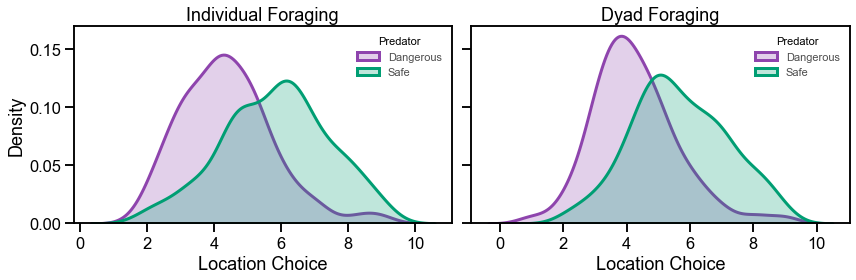

idv safe: m= 5.81984,       se=0.09985110505866651
idv dangerous: m= 4.379431746031745,       se=0.08743183566318878
group safe: m= 5.662932332576081,       se=0.0955176336798258
group dangerous: m= 4.2671448417440265,       se=0.08603187374428792
idv safe: var= 2.482590552177779
idv dangerous: var= 1.9034371459712762
group safe: var= 2.271780967604553
group dangerous: var= 1.8429693416883206
Safe Predator: t-value = 1.1355265211272116, p-value = 0.25670097006440695
Dangerous Predator: t-value = 0.9154219753721229, p-value = 0.3604131868335204


In [17]:
#is there a difference in location choice between different predators?
#in both group and individual condition
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# gg = df_group.groupby(['sub', 'room', 'predatorType'], as_index=False)[['finalStep', 'playerStep']].mean()
# gi = df_idv.loc[df_idv.trial>60].groupby(['sub', 'predatorType'], as_index=False)['choice'].mean()
# sns.barplot(data=gi, x='predatorType', y='choice', ax=axes[0])
# axes[0].set_ylabel('individual choice')
# sns.barplot(data=gg, x='predatorType', y='playerStep', ax=axes[1])
# #sns.swarmplot(data=gg, x='predatorType', y='stepChoice', ax=axes[1])
# axes[1].set_ylabel('group choice')
# axes[0].set_xticklabels(['safe', 'dangerous'])
# axes[1].set_xticklabels(['safe', 'dangerous'])


# Set the font for the plot
plt.rcParams['font.family'] = 'Arial'  


def get_predator_colors():
    return {0: "#009E73", 1: "#8E44AD"}  # Teal and Dark Purple

# Apply colors using the defined function
predator_colors = get_predator_colors()

# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Data processing for individual and group foraging
gg = df_group.query('step_rt<8 and playerStep>0').groupby(['subID', 'room', 'predatorType'], 
                  as_index=False)[['finalStep', 'playerStep', 'jointMoney']].mean()
gi = df_idv.query('trial>60').groupby(['subID', 'predatorType'], as_index=False)[['choice', 'reward']].mean()
# gi = df_idv2.groupby(['sub', 'predatorType'], as_index=False)[['choice', 'reward']].mean()
print([len(gg), len(gi)])
# Plot for individual foraging
sns.kdeplot(data=gi, hue='predatorType', x='choice', ax=axes[0], fill=True, palette=predator_colors, 
             linewidth=3)
axes[0].set_title('Individual Foraging')
axes[0].set_xlabel('Location Choice')
axes[0].legend(['Dangerous', 'Safe'], title='Predator', fontsize=11, frameon=False, 
               facecolor='darkgrey', labelcolor='#4D4D4D', 
               )
##decrease font of legend title
axes[0].get_legend().get_title().set_fontsize('11')

# Plot for group foraging
sns.kdeplot(data=gg, hue='predatorType', x='playerStep', ax=axes[1], fill=True, palette=predator_colors, 
            linewidth=3)
axes[1].set_title('Dyad Foraging')
axes[1].set_xlabel('Location Choice')
axes[1].legend(['Dangerous', 'Safe'], title='Predator', fontsize=11, frameon=False, 
               facecolor='darkgrey', labelcolor='#4D4D4D', 
               )
##decrease font of legend title
axes[1].get_legend().get_title().set_fontsize('11')

# Tight layout for better spacing
plt.tight_layout()
plt.show()

#print mean and CI
def confidence_interval(data, confidence=0.95):
    data = np.array(data)
    mean = np.mean(data)
    n = len(data)
    stderr = ss.sem(data)  # Standard error of the mean
    margin_of_error = stderr * ss.t.ppf((1 + confidence) / 2., n - 1)
    return mean, mean - margin_of_error, mean + margin_of_error

# Example usage:
print(f"idv safe: m= {np.mean(gi.query('predatorType==0')['choice'])}, \
      se={ss.sem(gi.query('predatorType==0')['choice'])}")
print(f"idv dangerous: m= {np.mean(gi.query('predatorType==1')['choice'])}, \
      se={ss.sem(gi.query('predatorType==1')['choice'])}")
print(f"group safe: m= {np.mean(gg.query('predatorType==0')['playerStep'])}, \
      se={ss.sem(gg.query('predatorType==0')['playerStep'])}")
print(f"group dangerous: m= {np.mean(gg.query('predatorType==1')['playerStep'])}, \
      se={ss.sem(gg.query('predatorType==1')['playerStep'])}")
# mean, lower_bound, upper_bound = confidence_interval(data)
# print(f"Mean: {mean}, 95% Confidence Interval: ({lower_bound}, {upper_bound})")

##calculate variance 
print(f"idv safe: var= {np.var(gi.query('predatorType==0')['choice'])}")
print(f"idv dangerous: var= {np.var(gi.query('predatorType==1')['choice'])}")
print(f"group safe: var= {np.var(gg.query('predatorType==0')['playerStep'])}")
print(f"group dangerous: var= {np.var(gg.query('predatorType==1')['playerStep'])}")


##do t-test between individual and group foraging for each predator type

# Perform t-test for safe predator
ttest_safe = ss.ttest_ind(gi.query('predatorType==0')['choice'], gg.query('predatorType==0')['playerStep'])

# Perform t-test for dangerous predator
ttest_dangerous = ss.ttest_ind(gi.query('predatorType==1')['choice'], gg.query('predatorType==1')['playerStep'])

# Print the results
print(f"Safe Predator: t-value = {ttest_safe.statistic}, p-value = {ttest_safe.pvalue}")
print(f"Dangerous Predator: t-value = {ttest_dangerous.statistic}, p-value = {ttest_dangerous.pvalue}")




In [18]:
def get_riskiness_wpair_by_predator_type(gi, gg):
    """
    Calculate riskiness with pair by predator type.
    takes in individual and group dataframes,
    """
    #merge individual and group data
    g = pd.merge(gi, gg, on=['subID', 'predatorType'])
    #rename a couple of columns
    g = g.rename({'choice':'individual', 'playerStep':'group'}, axis=1)
    g['predator']  = g['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')

    #add step / reward increase
    g['step_inc'] = g['group'] - g['individual']
    g['reward_inc'] = g['jointMoney'] / 2 - g['reward']

    #add risky / risk-averse
    group_stat = g.groupby(['room', 'predatorType'])['individual'].apply(lambda x: x.sort_values()).reset_index()
    group_stat['risky_wpair'] = ['risk-averse','risk-prone'] * (len(group_stat)//2)
    group_stat = pd.merge(g, group_stat).sort_values(by=['room', 'predatorType', 'individual'])

    return group_stat

In [19]:
def filter_groups_by_riskiness(group_stat):
    """
    Filter out groups where individual risk is the same.
    """
    c = group_stat.groupby(['room', 'predatorType']).size()
    filtered_out = c[c==2].index
    print(f"keep {len(filtered_out)} (room, predator)")
    group_stat_filtered = group_stat[group_stat.set_index(['room', 'predatorType']).index.isin(filtered_out)]
    assert(len(group_stat_filtered)<=num_subs*2)
    
    return group_stat_filtered

In [20]:
# get group stats
group_stat = get_riskiness_wpair_by_predator_type(gi, gg)


# #in cluster analyses, filter out groups where individual risk is the same
# c = group_stat.groupby(['room', 'predatorType']).size()
# filtered_out = c[c==2].index
# print(f"keep {len(filtered_out)} (room, predator)")
# group_stat_filtered = group_stat[group_stat.set_index(['room', 'predatorType']).index.isin(filtered_out)]
# assert(len(group_stat_filtered)<=num_subs*2)
# group_stat_filtered.head()

print(ss.ttest_rel(group_stat['individual'], group_stat['group']))


## ttest on idv vs group step for RA and RP
print("RA: dyad vs idv step:")
print(ss.ttest_rel(group_stat.query('risky_wpair=="risk-averse"')['group'], group_stat.query('risky_wpair=="risk-averse"')['individual']))
print("RP: dyad vs idv step:")
print(ss.ttest_rel(group_stat.query('risky_wpair=="risk-prone"')['group'], group_stat.query('risky_wpair=="risk-prone"')['individual']))
# group_stat['diff'] = group_stat['individual'] - group_stat['group']
# # print(ss.ttest_ind(group_stat['diff'], 0))


# ##ttest of diff between group and idv for each predator type
# print(ss.ttest_ind(group_stat.query('predatorType==0')['diff'], 0))
# print(ss.ttest_ind(group_stat.query('predatorType==1')['diff'], 0))



TtestResult(statistic=2.386109560450428, pvalue=0.017392207660546, df=509)
RA: dyad vs idv step:
TtestResult(statistic=3.3585273414553813, pvalue=0.000903872343093096, df=254)
RP: dyad vs idv step:
TtestResult(statistic=-7.0592066892523055, pvalue=1.59497353673516e-11, df=254)


In [21]:

def visualize_raw_data(g):
    fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)  
    plt.subplots_adjust(hspace=0.4)

    x_map = {'individual': 0, 'group': 1}

    for i, pred_type in enumerate([0, 1]):
        ax = axes[i]
        
        # Subset and sort
        data = g.loc[g.predatorType == pred_type].sort_values(by=['room', 'risky_wpair'])
        
        # Melt data
        melted_data = data[['subID', 'risky_wpair', 'individual', 'group']].melt(
            id_vars=['subID', 'risky_wpair'], 
            value_vars=['individual', 'group'], 
            var_name='variable', 
            value_name='value'
        )
        
        # Map variable to numeric + jitter
        noise = 0.05
        melted_data['y_jittered'] = melted_data['variable'].map(x_map) + \
                                    np.random.normal(0, noise, size=melted_data.shape[0])

        for phase, y_value in x_map.items():
            for order in risk_palette.keys():
                subset = melted_data[(melted_data['variable'] == phase) & (melted_data['risky_wpair'] == order)]
                
                kde = sns.kdeplot(subset['value'], linewidth=0, common_norm=False, color='gray', ax=ax)

                x_vals = kde.lines[-1].get_xdata()
                y_vals = kde.lines[-1].get_ydata()
                offset = noise * 2

                if phase == "individual":
                    ax.fill_betweenx(y=y_value - y_vals * 0.7 - offset,
                                     x1=x_vals, x2=y_value - offset,
                                     alpha=0.1, color=risk_palette[order])
                elif phase == "group":
                    ax.fill_betweenx(y=y_value + y_vals * 0.7 + offset,
                                     x1=x_vals, x2=y_value + offset,
                                     alpha=0.1, color=risk_palette[order])

        # Line plot
        sns.lineplot(data=melted_data, y='y_jittered', x='value', hue='risky_wpair',
                     units='subID', estimator=None, ax=ax, 
                     palette=risk_palette, linewidth=0.2, alpha=0.4, legend=False)

        # Scatter plot
        sns.scatterplot(data=melted_data, y='y_jittered', x='value', hue='risky_wpair',
                        palette=risk_palette, s=20, ax=ax, legend=False, alpha=0.4)

        # Pointplot for means
        sns.pointplot(data=melted_data, y='variable', x='value', hue='risky_wpair',
                      palette=risk_palette, scale=1, ax=ax, ci=95, dodge=0.1, legend=False)

        # Set yticks as phase labels
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['Individual', 'Dyad'], rotation=90, va='center', fontsize=19)

        # Axis labels
        ax.set_ylabel('')
        ax.set_xlabel('Foraging Step', labelpad=15, fontsize=19)

        # Axis limits
        ax.set_xlim(0.5, 9.5)

    # Titles
    axes[0].set_title('Low-Threat Predator', fontsize=20)
    # axes[0].set_facecolor('orange')
    # axes[0].patch.set_alpha(0.05)
    axes[1].set_title('High-Threat Predator', fontsize=20)
    # axes[1].set_facecolor('blue')
    # axes[1].patch.set_alpha(0.05)

    # Custom legend
    legend_handles = [
        Line2D([0], [0], color='w', markerfacecolor=risk_palette['risk-averse'], 
               markersize=10, marker='o', label='risk-averse'),
        Line2D([0], [0], color='w', markerfacecolor=risk_palette['risk-prone'], 
               markersize=10, marker='o', label='risk-prone')
    ]
    fig.legend(handles=legend_handles, title='Riskiness within Dyad', ncol=2, 
               bbox_to_anchor=(0.9, 0.074), frameon=True, fontsize=13, title_fontsize=13)

    # plt.tight_layout()
    if save:
        plt.savefig(f'../paper_figs/{folder}/behavior_{folder}.png', 
                bbox_inches='tight', dpi=200)


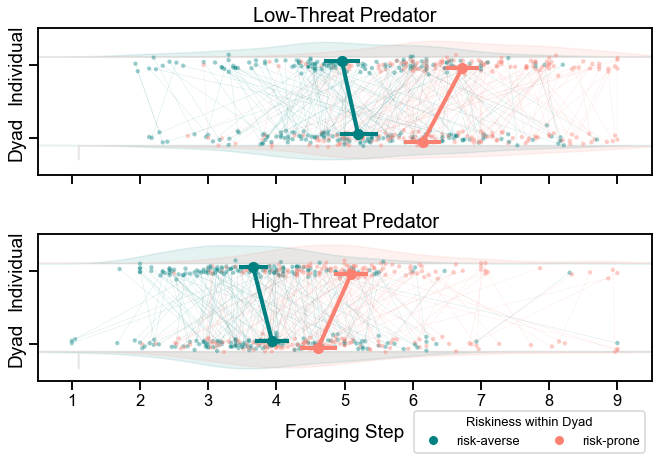

In [22]:
visualize_raw_data(group_stat)

keep 245 (room, predator)
                     sum_sq     df         F    PR(>F)
C(predatorType)    1.982258    1.0  2.881753  0.090227
C(risky_wpair)     0.027462    1.0  0.039924  0.841712
Residual         334.990431  487.0       NaN       NaN
TtestResult(statistic=-0.19942606856208744, pvalue=0.8420125373236539, df=488.0)


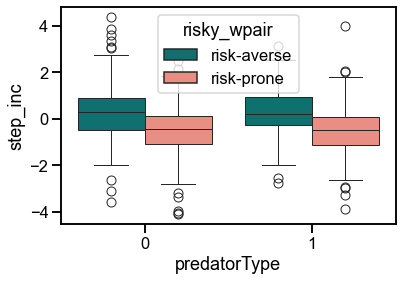

In [23]:
#compare money increase between risky and risk-averse individuals
group_stat_filtered = filter_groups_by_riskiness(group_stat)
sns.boxplot(data=group_stat_filtered, y='step_inc', x='predatorType', hue='risky_wpair', palette=risk_palette)

#run a anova - no obvious difference between predator type and riskiness
group_stat_filtered['abs_step_inc'] = np.abs(group_stat_filtered['step_inc'])
model = smf.ols('abs_step_inc ~ C(predatorType) + C(risky_wpair)', data=group_stat_filtered)
anova_table = sm.stats.anova_lm(model.fit(), typ=2)
print(anova_table)

#then t-test
print(ss.ttest_ind(group_stat_filtered.query('risky_wpair=="risk-averse"')['abs_step_inc'], 
                   group_stat_filtered.query('risky_wpair=="risk-prone"')['abs_step_inc'],))
# print(ss.ttest_1samp(group_stat_filtered.query('risky_wpair=="risk-averse"')['step_inc'], 0))
# sample =group_stat_filtered.query('risky_wpair=="risk-prone"')['step_inc']
# mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
# std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
# cohens_d = mean_diff / std_dev
# print(f"Cohen's d for risk-averse: {cohens_d}")

# print(ss.ttest_1samp(group_stat_filtered.query('risky_wpair=="risk-prone"')['step_inc'], 0))
# sample = group_stat_filtered.query('risky_wpair=="risk-prone"')['step_inc']
# mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
# std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
# cohens_d = mean_diff / std_dev
# print(f"Cohen's d for risk-prone: {cohens_d}")

In [24]:
# group_stat = pd.merge(group_stat, df_group.query('selfBlame>0').groupby(['subID'], as_index=False)['selfBlame'].mean())
# model = smf.ols('selfBlame ~ C(predatorType) + C(risky_wpair)', data=group_stat)
# anova_table = sm.stats.anova_lm(model.fit(), typ=2)
# print(anova_table)


ego_bias = df_group.query('selfBlame>0').groupby(['subID', 'attack', 'predatorType'], as_index=False)['selfBlame'].mean()
# ego_bias = pd.merge(ego_bias.query('attack==True'), ego_bias.query('attack==False'), on=['subID', 'predatorType'], suffixes=['_lose', '_win'])
# ego_bias['ego_bias'] = ego_bias['selfBlame_win'] - ego_bias['selfBlame_lose']
# ego_bias = pd.merge(ego_bias, group_stat)
# model = smf.ols('ego_bias ~ C(predatorType) + C(risky_wpair)', data=ego_bias)
model = smf.ols('selfBlame ~ C(predatorType) + C(attack)', data=ego_bias)
anova_table = sm.stats.anova_lm(model.fit(), typ=2)
print(anova_table)

                    sum_sq     df          F        PR(>F)
C(predatorType)   0.001866    1.0   0.123017  7.258599e-01
C(attack)         0.693461    1.0  45.718547  2.326204e-11
Residual         15.061877  993.0        NaN           NaN


In [25]:
# #compare money increase between risky and risk-averse individuals
group_stat_filtered = filter_groups_by_riskiness(group_stat)


keep 245 (room, predator)


PearsonRResult(statistic=-0.41671748449909757, pvalue=7.659359143139388e-23)


<Figure size 864x288 with 0 Axes>

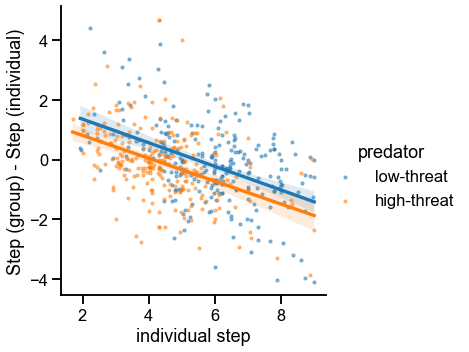

In [26]:
plt.figure(figsize=(12, 4))
sns.lmplot(data = group_stat, x='individual', y='step_inc', hue='predator',
           scatter_kws={'s':10, 'alpha':0.5})
plt.ylabel('Step (group) - Step (individual)')
plt.xlabel('individual step')
print(ss.pearsonr(group_stat['individual'], group_stat['step_inc']))
#sns.regplot(data = g.loc[g.predatorType==1], x='individual', y='grp_idv_step_diff')

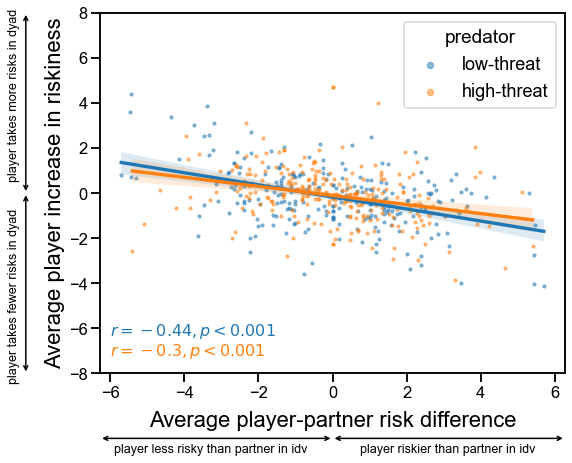

In [27]:
group_stat['self_partner_risk_diff'] = group_stat.groupby(['room', 'predatorType'])['individual'].diff()
group_stat['self_partner_risk_diff'] = group_stat.groupby(['room', 'predatorType'])['self_partner_risk_diff'].transform(lambda x: x.fillna(-x.iloc[-1]))

# sns.regplot(data = g.query('predatorType==0'), x='self_partner_risk_diff', y='step_inc',
#            scatter=False, label='safe')
# sns.regplot(data = g.query('predatorType==1'), x='self_partner_risk_diff', y='step_inc',
#            scatter=False, label='dangerous')
# plt.ylabel('step (dyad) - step (individual)')
# plt.xlabel('player-partner individual step difference')
myfig = sns.lmplot(data = group_stat, x='self_partner_risk_diff', y='step_inc', hue='predator', 
           scatter_kws={'s':10, 'alpha':0.5}, legend=False, 
           aspect=1.25, height=6) #aspect = width / height
plt.legend(title='predator', fontsize=18, title_fontsize=19, markerscale=2, loc='upper right')

# set x, y label
# plt.ylabel('$player_{dyad} - player_{individual}$')
# plt.xlabel('$player_{individual} - partner_{individual}$')
plt.ylabel('Average player increase in riskiness', fontsize=22)
plt.xlabel('Average player-partner risk difference', labelpad=10, fontsize=22)

# Add a full border (spines) around the plot
for ax in myfig.axes.flat:
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

#test significance
r0, p0 = ss.pearsonr(group_stat.query('predatorType==0')['self_partner_risk_diff'], 
                     group_stat.query('predatorType==0')['step_inc'])
r1, p1 = ss.pearsonr(group_stat.query('predatorType==1')['self_partner_risk_diff'], 
                     group_stat.query('predatorType==1')['step_inc'])

# Annotate plot
plt.ylim([-8, 8])
plt.annotate(f"$r={round(r0, 2)}, p<0.001$", (-6, -6.3), fontsize=16, color='#1F77B4')
plt.annotate(f"$r={round(r1, 2)}, p<0.001$", (-6, -7.2), fontsize=16, color='#FF7F0E')

# add arrows below
ft=12.5
myoffset = 0.04
#for x-axis
y_level =-0.18
plt.annotate('', xy=(0, y_level), xytext=(0.5, y_level), #from (x,y) to (xtext, ytext) relateive to (1,1) picture
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops
            =dict(arrowstyle='<->', lw=1.5))
plt.annotate('', xy=(0.5, y_level), xytext=(1, y_level), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('player less risky than partner in idv', xy=(0.03, y_level-myoffset), 
             xycoords='axes fraction', ha='left', fontsize=ft)
plt.annotate('player riskier than partner in idv', xy=(0.56, y_level-myoffset), 
             xycoords='axes fraction', ha='left', fontsize=ft)
#for y-axis
x_lvl = -0.16
plt.annotate('', xy=(x_lvl, 0.5), xytext=(x_lvl, 1), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('', xy=(x_lvl, 0.5), xytext=(x_lvl, 0), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('player takes more risks in dyad', xy=(x_lvl-myoffset, 0.54), 
             xycoords='axes fraction', ha='left', fontsize=ft, rotation=90)
plt.annotate('player takes fewer risks in dyad', xy=(x_lvl-myoffset, -0.02),
             xycoords='axes fraction', ha='left', fontsize=ft, rotation=90)
if save: 
    plt.savefig(f'../paper_figs/{folder}/grp_reg_{folder}.png', 
                bbox_inches='tight', dpi=200)

PearsonRResult(statistic=-0.20673711898221905, pvalue=0.0008967697886574501)
PearsonRResult(statistic=0.045671453831816325, pvalue=0.46777105305286537)


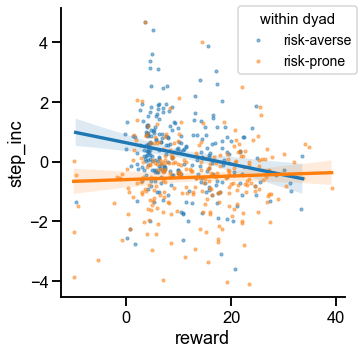

In [28]:
#compromise is independent of performance ..?
sns.lmplot(data=group_stat, y='step_inc', x='reward', hue='risky_wpair', 
           scatter_kws={'s':10, 'alpha':0.5}, legend=None)
plt.legend(title='within dyad', bbox_to_anchor=(0.6, 0.75), fontsize=14, title_fontsize=15)
#test significance
print(ss.pearsonr(group_stat.query('risky_wpair=="risk-averse"')['reward'], 
                    group_stat.query('risky_wpair=="risk-averse"')['step_inc']))
print(ss.pearsonr(group_stat.query('risky_wpair=="risk-prone"')['reward'], 
                    group_stat.query('risky_wpair=="risk-prone"')['step_inc']))

increase in reward id dyad: 
TtestResult(statistic=5.110116008852118, pvalue=4.562142113082698e-07, df=509)


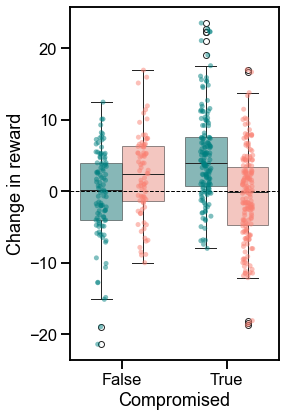

In [29]:
#reward increase by riskiness and predator
plt.figure(figsize=(3.75, 6.5))
group_stat['step_inc_towards_partner']=group_stat.apply(lambda row: row['step_inc'] if row['risky_wpair']=="risk-averse" else -row['step_inc'], axis=1)
group_stat['compromised'] = group_stat['step_inc_towards_partner']>0
group_stat['predator'] = group_stat['predatorType'].apply(lambda x: 'low-threat' if x==0 else 'high-threat')
# sns.swarmplot(data = group_stat, x='compromised', y='reward_inc', hue='risky_wpair', dodge=True, alpha=0.4, s=2,
#               legend=False)
sns.boxplot(data = group_stat, x='compromised', y='reward_inc',
            hue='risky_wpair', palette=risk_palette, 
            flierprops=dict(markersize=6), boxprops=dict(alpha=0.5), )
sns.stripplot(data = group_stat, x='compromised', y='reward_inc', dodge=True,
            hue='risky_wpair', palette=risk_palette, alpha=0.5
)
print("increase in reward id dyad: ")
print(ss.ttest_1samp(group_stat['reward_inc'], 0))
# plt.legend(loc='lower center', fontsize=14, title_fontsize=15, title='riskiness within dyad')
plt.legend().remove()
plt.ylabel('Change in reward')
plt.xlabel('Compromised')
# plt.ylabel(r'$reward_{dyad}$ - $reward_{idv}$')
plt.axhline(y=0, ls='--', color='black', lw=1)

if save:
    plt.savefig(f'../paper_figs/{folder}/reward_by_compromise{folder}.png', 
            bbox_inches='tight', dpi=200)


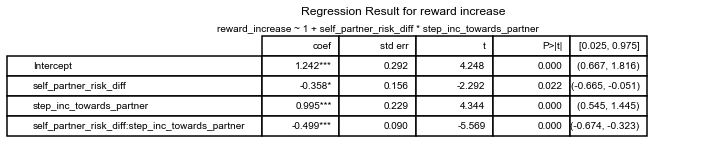

In [30]:

#run regression
# model = smf.ols('reward_inc ~ C(risky_wpair) * C(compromised)', data=group_stat).fit()
reward_model = smf.ols('reward_inc ~ self_partner_risk_diff * step_inc_towards_partner', 
                           data=group_stat).fit()
# model = smf.ols('reward_inc ~ C(predator) * C(compromised)', data=group_stat).fit()

with open(f'../model_fits/regs/reward_reg_summary_continuous_{folder}.txt', "w") as f:
    f.write(reward_model .summary().as_text())

reward_formula = 'reward_increase ~ 1 + self_partner_risk_diff * step_inc_towards_partner'
title = "Regression Result for reward increase"
save_reg_to_table(reward_model , 4, reward_formula, title, folder)
# ss.ttest_ind(group_stat.query('risky_wpair=="risk-prone" and predatorType==0')['reward_inc'], 
#                group_stat.query('risky_wpair=="risk-prone" and predatorType==1')['reward_inc'])

(array([ 3.,  7., 22., 36., 55., 63., 36., 22.,  7.,  3.]),
 array([-5.4 , -4.32, -3.24, -2.16, -1.08,  0.  ,  1.08,  2.16,  3.24,
         4.32,  5.4 ]),
 <BarContainer object of 10 artists>)

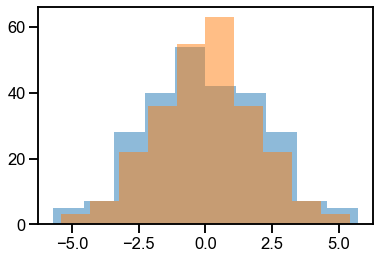

In [31]:
# regress delta_reward on cumulative_reward
# d = group_stat.groupby(['room', 'predatorType'], as_index=False)[['reward', 'reward_inc']].mean()


# sns.lmplot(data=group_stat, y='reward_inc', x='reward', hue='risky_wpair', 
#            scatter_kws={'s':10, 'alpha':0.5}, legend=None)
# sns.lmplot(data=d, y='reward_inc', x='reward', hue='predatorType', 
        #    scatter_kws={'s':10, 'alpha':0.5}, legend=None)
plt.hist(group_stat.query('predatorType==0')['self_partner_risk_diff'], alpha=0.5)
plt.hist(group_stat.query('predatorType==1')['self_partner_risk_diff'], alpha=0.5)

# maybe: dyads with higher risk diff compromise

<Axes: xlabel='playerStep', ylabel='step_rt'>

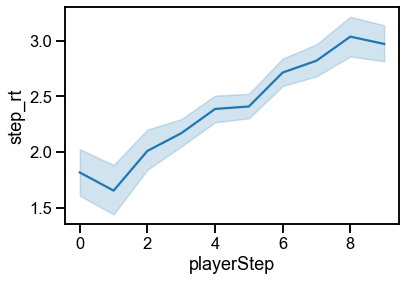

In [32]:
# take a look at rt
d = df_group.query('step_rt<8').groupby(['subID', 'playerStep'], as_index=False)['step_rt'].mean()
sns.lineplot(data = d, x='playerStep', y='step_rt')

In [33]:
# run regression on RT
# higher self-prediction discrepency -> longer RT
rt_reg = df_group.query('step_rt<8 and prediction>0').copy()
rt_reg['abs_playerStep_prediction_diff'] = np.abs(rt_reg['playerStep'] - rt_reg['prediction'])
rt_reg['log_step_rt'] = np.log(rt_reg['step_rt'])
rt_model = smf.mixedlm('log_step_rt ~ abs_playerStep_prediction_diff + playerStep', 
                    data = rt_reg,
                    groups = rt_reg['subID'],
                    re_formula = '~ abs_playerStep_prediction_diff + playerStep'
                ).fit()
print(rt_model.summary())

with open(f'../paper_figs/{folder}/rt_reg_summary_{folder}.txt', "w") as f:
    f.write(rt_model.summary().as_text())


                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            log_step_rt
No. Observations:            14197              Method:                        REML       
No. Groups:                  250                Scale:                         0.1224     
Min. group size:             10                 Log-Likelihood:                -6017.6718 
Max. group size:             60                 Converged:                     Yes        
Mean group size:             56.8                                                         
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        0.278    0.034  8.227 0.000  0.211  0.344
abs_playerStep_prediction_

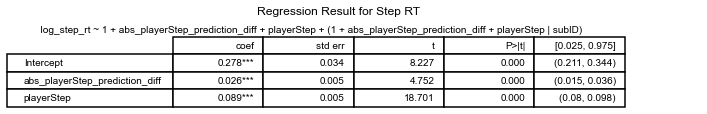

In [34]:
rt_formula = '  log_step_rt ~ 1 + abs_playerStep_prediction_diff + playerStep + (1 + abs_playerStep_prediction_diff + playerStep | subID)'
title = "Regression Result for Step RT"
save_reg_to_table(rt_model, 3, rt_formula, title, folder)

In [35]:
# correlations - no diff early and later
# corr_df1 = (
# df_group.query('trial <= 10 and playerID == 1')
#     .groupby('room')
#     .apply(lambda g: g['playerStep'].corr(g['partnerStep']))
#     .reset_index(name='corr_player_partner')
# )

# corr_df2 = (
# df_group.query('trial > 20 and playerID == 1')
#     .groupby('room')
#     .apply(lambda g: g['playerStep'].corr(g['partnerStep']))
#     .reset_index(name='corr_player_partner')
# )
# corr_df = pd.merge(corr_df1, corr_df2, on=['room'], suffixes=("_early", "_later")).dropna()
# print(ss.ttest_rel(corr_df['corr_player_partner_early'], corr_df['corr_player_partner_later']))


## trial by trial compromise

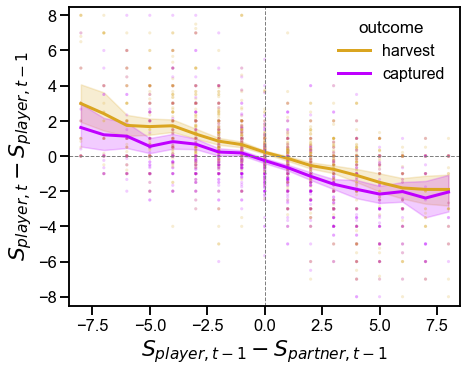

In [36]:
df_cleaned = df_group.sort_values(by=['room', 'block', 'trial'])
df_cleaned['predator'] = df_cleaned['predatorType'].apply(lambda x: 'safe' if x==0 else 'dangerous')
df_cleaned['partner_changed'] = df_cleaned['partnerStep'] - df_cleaned.groupby(['subID', 'block'])['partnerStep'].shift()
df_cleaned['partner_changed_rel'] = df_cleaned['partner_changed'] * np.sign(df_cleaned.groupby(['subID', 'block'])['player_partner_diff'].shift())
df_cleaned['player_change'] = df_cleaned.groupby(['subID', 'block'])['playerStep'].shift(-1) -df_cleaned['playerStep']
df_cleaned['future_step_rt'] = df_cleaned.groupby(['subID', 'block'])['step_rt'].shift(-1)
df_cleaned['player_change_rel'] = -df_cleaned['player_change'] * np.sign(df_cleaned['player_partner_diff'])
df_cleaned = df_cleaned.query('player_change<=8 and player_change>=-8 and player_partner_diff<=8 and player_partner_diff>=-8')
# sns.lmplot(data=df_cleaned, x='partner_changed_rel', y='player_future_change_rel', scatter=False)
# sns.lineplot(data=df_cleaned.groupby(['sub', 'player_partner_diff', 'predator'], as_index=False)['player_change'].mean(), 
#              x='player_partner_diff', y='player_change', hue='predator', hue_order=['safe', 'dangerous'])
# plt.ylim([-6, 6])
# plt.xlabel('player partner step difference')
# plt.ylabel('player step change')


##small plot
plt.figure(figsize=(7, 5.5))

sns.lineplot(data=df_cleaned.groupby(['subID', 'player_partner_diff', 'attack'],
                                     as_index=False)['player_change'].mean(), 
             x='player_partner_diff', y='player_change', hue='attack', 
             linewidth=3,hue_order=[0, 1], palette=outcome_colors,
            )
              
##scatter on top
sns.scatterplot(data=df_cleaned.groupby(['subID', 'player_partner_diff', 'attack'],
                                     as_index=False)['player_change'].mean(),
                x='player_partner_diff',
                y='player_change', hue='attack',
                hue_order=[0, 1], palette=outcome_colors,
                s=10, alpha=0.2)

               
plt.ylim([-8.5, 8.5])
plt.xlim([-8.5, 8.5])
# plt.xlabel('player partner step difference')
# plt.ylabel('player step change')
plt.axhline(0, color='grey', linewidth=1, linestyle='--')
plt.axvline(0, color='grey', linewidth=1, linestyle='--')


##change legend labels by creating two lines of blue and orange
legend_handles=[Line2D([0], [0], color= outcome_colors[0], lw=3),
                Line2D([0], [0], color=outcome_colors[1], lw=3)]

plt.legend(legend_handles, ['harvest', 'captured'], title='outcome', 
           bbox_to_anchor=(0.65, 0.7), fontsize=16, 
           frameon=False,
           title_fontsize=17)



##change x, y labels
# plt.legend().remove()
plt.xlabel(r'$S_{player, t-1} - S_{partner, t-1}$', fontsize=22, labelpad=5)
plt.ylabel(r'$S_{player, t} - S_{player, t-1}$', fontsize=22)

if save:
    plt.savefig(f'../paper_figs/{folder}/trial_reg2_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [37]:
df_cleaned.to_csv(f'../processed_data/reg_{folder}.csv')

In [38]:
# run regression
df_change_reg = df_cleaned.query('trial>1 and trial<30 and step_rt<8 and future_step_rt<8') #remove first and last trial and auto choices
df_change_reg = df_change_reg[['player_change', 'player_partner_diff', 'outcome', 'partner_changed', 'subID', 'trial', 'block', 'partnerStep', 'playerStep']].dropna() #remove first and last trial
print(len(df_change_reg['subID'].unique()))

change_model = smf.mixedlm('player_change ~ player_partner_diff * outcome + partner_changed', 
                    data = df_change_reg,
                    groups = df_change_reg['subID'],
                    re_formula = '~ player_partner_diff * outcome + partner_changed'
                ).fit()
print(change_model.summary())

with open(f'../model_fits/regs/stepchange_reg_summary_{folder}.txt', "w") as f:
    f.write(change_model.summary().as_text())

250
                                    Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 player_change
No. Observations:                   13494                   Method:                             REML         
No. Groups:                         250                     Scale:                              1.7998       
Min. group size:                    30                      Log-Likelihood:                     -23796.0773  
Max. group size:                    56                      Converged:                          Yes          
Mean group size:                    54.0                                                                     
-------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------

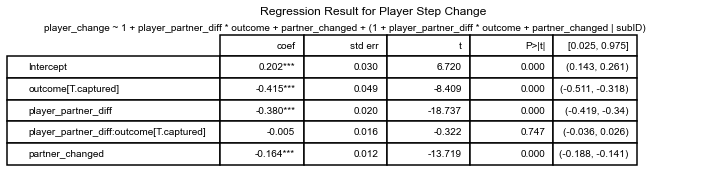

In [39]:
change_formula = 'player_change ~ 1 + player_partner_diff * outcome + partner_changed + (1 + player_partner_diff * outcome + partner_changed | subID)'
title = "Regression Result for Player Step Change"
save_reg_to_table(change_model, 5, change_formula, title)

                                    Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 player_change
No. Observations:                   13494                   Method:                             ML           
No. Groups:                         250                     Scale:                              1.5700       
Min. group size:                    30                      Log-Likelihood:                     -23069.5879  
Max. group size:                    56                      Converged:                          Yes          
Mean group size:                    54.0                                                                     
-------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------

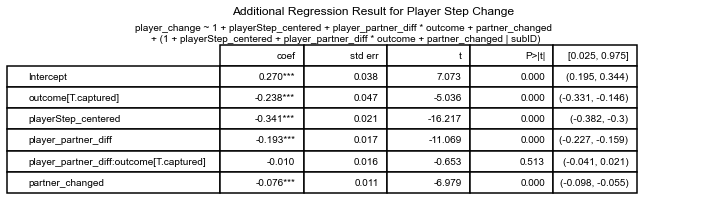

In [40]:
# additional regression controlling for player step
df_change_reg = df_cleaned.query('step_rt<8 and future_step_rt<8') #remove first and last trial and auto choices
# df_change_reg = pd.merge(df_change_reg, df_change_reg.groupby(['subID', 'predatorType'], as_index=False)['playerStep'].mean().rename({'playerStep':'avg_playerStep'}, axis=1))
# df_change_reg['mc_playerStep'] = df_change_reg['playerStep'] - df_change_reg['avg_playerStep']
df_change_reg = df_change_reg[['player_change', 'player_partner_diff', 'outcome', 'partner_changed', 'subID', 'trial', 'predatorType', 'playerStep', 'partnerStep']].dropna() #remove first and last trial
df_change_reg['playerStep_centered'] = df_change_reg['playerStep'] - 4.5 #center this
change_model2 = smf.mixedlm('player_change ~ playerStep_centered + player_partner_diff * outcome + partner_changed', 
                    data = df_change_reg,
                    groups = df_change_reg['subID'],
                    re_formula = '~ playerStep_centered + player_partner_diff * outcome + partner_changed'
                ).fit(reml=False, method="lbfgs", maxiter=2000)
print(change_model2.summary())

change_formula = 'player_change ~ 1 + playerStep_centered + player_partner_diff * outcome + partner_changed \n+ (1 + playerStep_centered + player_partner_diff * outcome + partner_changed | subID)'
title = "Additional Regression Result for Player Step Change\n"
save_reg_to_table(change_model2, 6, change_formula, title)

TtestResult(statistic=2.2120717155181655, pvalue=0.027417574150785738, df=495.0)

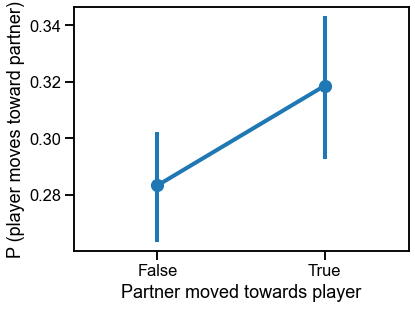

In [41]:
# test for reciprocity: if partner moves towards player on the previous round, will player move towards partner on the next round?
reciprocity = df_cleaned.copy()
# binarize
reciprocity['partner_changed'] = reciprocity['partner_changed_rel'] >0 
reciprocity['player_change'] = reciprocity['player_change_rel'] >0 

plt.figure(figsize=(6,4.5))
d = reciprocity.groupby(['subID', 'partner_changed'], as_index=False)['player_change'].mean()
sns.pointplot(data = d, x='partner_changed', y='player_change')
plt.ylabel('P (player moves toward partner)')
plt.xlabel('Partner moved towards player', labelpad=5)
ss.ttest_ind(d.query('partner_changed==True')['player_change'], d.query('partner_changed==False')['player_change'])

# Group dynamics clustering

In [42]:
##expand g so that grp_idv_step_diff is split into two columns based on order

#filter groups by riskiness
group_stat_filtered = filter_groups_by_riskiness(group_stat)
# group_stat_filtered['grp_idv_step_diff_risk_prone'] = None
# group_stat_filtered['grp_idv_step_diff_risk_averse'] = None

##take absolute of self_partner_risk_diff 
group_stat_filtered['idvDiff'] = np.abs(group_stat_filtered['self_partner_risk_diff'])

# Populate the columns based on the 'order' column
group_stat_filtered.loc[group_stat_filtered['risky_wpair'] == 'risk-prone', 'grp_idv_step_diff_risk_prone'] = group_stat_filtered['step_inc']
group_stat_filtered.loc[group_stat_filtered['risky_wpair'] == 'risk-averse', 'grp_idv_step_diff_risk_averse'] = group_stat_filtered['step_inc']

# Group by `sub` and `predatorType`, and aggregate
collapsed_g = group_stat_filtered.groupby(['room', 'predatorType']).agg({
    'individual': 'mean',  # or use 'mean'/'sum' if needed
    'idvDiff': 'first',  # or use 'mean'/'sum' if needed
    'reward': 'sum',  # or use 'mean'/'sum' if needed
    'jointMoney': 'mean',  # or use 'mean'/'sum' if needed
    'finalStep': 'first',  # or use 'mean'/'sum' if needed
    'group': 'first',  # or use 'mean'/'sum' if needed
    'grp_idv_step_diff_risk_prone': 'sum',  # Summing non-null values per group
    'grp_idv_step_diff_risk_averse': 'sum',  # Summing non-null values per group
    'predator': 'first'  # or use 'mean'/'sum' if needed
}).reset_index()

# Drop rows with NaN in both `grp_idv_step_diff_risk_prone` and `grp_idv_step_diff_risk_averse`
# collapsed_g.dropna(subset=['grp_idv_step_diff_risk_prone', 'grp_idv_step_diff_risk_averse'], how='all', inplace=True)

# Ensure that `grp_idv_step_diff_risk_prone` and `grp_idv_step_diff_risk_averse` columns are numeric
collapsed_g['grp_idv_step_diff_risk_prone'] = pd.to_numeric(collapsed_g['grp_idv_step_diff_risk_prone'], errors='coerce')
collapsed_g['grp_idv_step_diff_risk_averse'] = pd.to_numeric(collapsed_g['grp_idv_step_diff_risk_averse'], errors='coerce')

# Fill NaN values if needed (e.g., with 0 or another value)
# collapsed_g['grp_idv_step_diff_risk_prone'].fillna(0, inplace=True)
# collapsed_g['grp_idv_step_diff_risk_averse'].fillna(0, inplace=True)

## add a new column based on diff - low or high - based on median 

# Calculate the median of the 'diff' column
median_diff = collapsed_g['idvDiff'].median()

collapsed_g['diffCategory'] = np.where(collapsed_g['idvDiff'] > median_diff, 'high', 'low')

sns.set_context("talk")

keep 245 (room, predator)


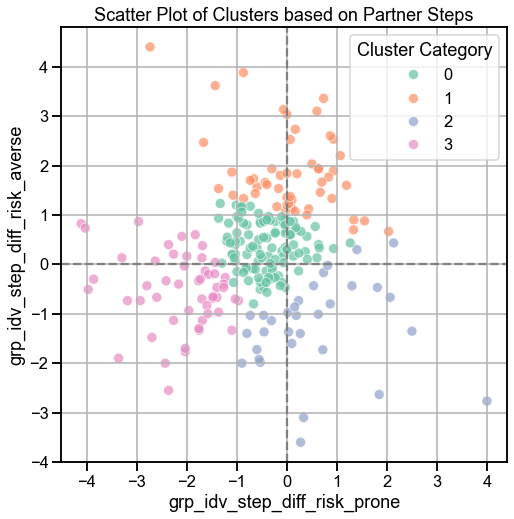

In [43]:
#people with small risk difference compromise and big risk difference compensate?
#do clustering on this and see if it correlates with behavioral data?
num_clusters = 4 #commented method shows that 4 is best
kmeans = KMeans(n_clusters=num_clusters, n_init=1)  # Adjust the number of clusters as needed
collapsed_g['cluster'] = kmeans.fit_predict(collapsed_g[['grp_idv_step_diff_risk_prone', 'grp_idv_step_diff_risk_averse']])

# Scatter plot to show clusters
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x='grp_idv_step_diff_risk_prone', 
    y='grp_idv_step_diff_risk_averse', 
    hue='cluster', 
    palette='Set2', 
    data=collapsed_g, 
    s=100, 
    alpha=0.7
)

plt.axhline(0, color='gray', ls='--')
plt.axvline(0, color='gray', ls='--')
plt.title('Scatter Plot of Clusters based on Partner Steps')
plt.legend(title='Cluster Category')
plt.grid(True)


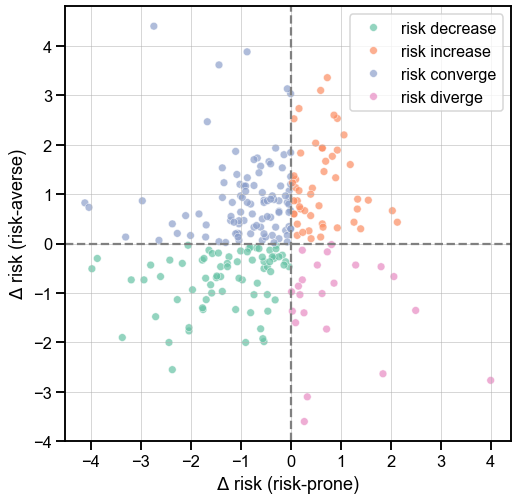

In [44]:
#manully separate them into 4 quadrants
def get_cluster(row):
    if row['grp_idv_step_diff_risk_prone'] >0:
        if row['grp_idv_step_diff_risk_averse'] >0:
            cluster = "risk increase"
        else:
            cluster = "risk diverge"
    else:
        if row['grp_idv_step_diff_risk_averse'] <0:
            cluster = "risk decrease"
        else:
            cluster = "risk converge"
    return cluster

collapsed_g['cluster'] = collapsed_g.apply(get_cluster, axis=1)
clusters = ['risk decrease', 'risk increase', 'risk converge', 'risk diverge']
# Scatter plot to show clusters
plt.figure(figsize=(8, 8))
sns.scatterplot(
    x='grp_idv_step_diff_risk_prone', 
    y='grp_idv_step_diff_risk_averse', 
    hue='cluster', 
    palette='Set2', 
    data=collapsed_g, 
    hue_order=clusters,
    s=60, 
    alpha=0.7
)

plt.axhline(0, color='gray', ls='--')
plt.axvline(0, color='gray', ls='--')
plt.xlabel('$\Delta$ risk (risk-prone)')
plt.ylabel('$\Delta$ risk (risk-averse)')
plt.legend(fontsize=16)
plt.grid(True, linewidth=0.5)
if save:
    plt.savefig(f'../paper_figs/{folder}/category_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [45]:
def mybar(**kwargs):
    sns.barplot(alpha=0.4, palette='Set2', order=clusters, **kwargs)

def myswarm(**kwargs):
    sns.swarmplot(palette='Set2', order=clusters, alpha=0.8, s=3, **kwargs)

                sum_sq     df         F    PR(>F)
C(cluster)   16.498027    3.0  3.931408  0.009144
Residual    337.116265  241.0       NaN       NaN
t = -3.402533407313898, p = 0.0007806231026848482


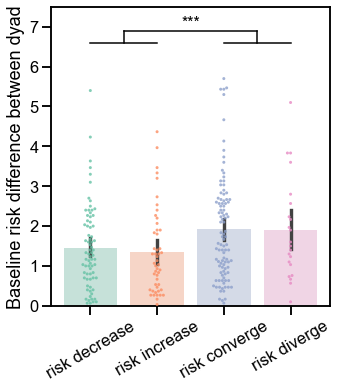

In [46]:
# Assume you already have 'collapsed_g' and 'clusters' defined
fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))

# Plot swarm and barplot
myswarm(data=collapsed_g, x='cluster', y='idvDiff')
mybar(data=collapsed_g, x='cluster', y='idvDiff')

plt.xticks(rotation=30)
plt.ylabel('Baseline risk difference between dyad')
plt.xlabel('')
plt.ylim([0, 7.5])

# Run ANOVA
model = smf.ols('idvDiff ~ C(cluster)', data=collapsed_g).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# # --- Create combined groups ---
# # Define which clusters go into each combined group
group1_clusters = ['risk decrease', 'risk increase']  # <-- replace with your actual cluster labels
group2_clusters = ['risk converge', 'risk diverge']  # <-- replace with your actual cluster labels

# Create a temporary DataFrame with relabeled groups
collapsed_g_combined = collapsed_g.copy()
collapsed_g_combined['comparison_group'] = collapsed_g_combined['cluster'].apply(
    lambda x: 'Group1+2' if x in group1_clusters else ('Group3+4' if x in group2_clusters else 'Other')
)
t, p = ss.ttest_ind(collapsed_g_combined.query('comparison_group=="Group1+2"')['idvDiff'],
            collapsed_g_combined.query('comparison_group=="Group3+4"')['idvDiff'])
print(f"t = {t}, p = {p}")

y_h = 6.9
y_l = 6.6
# Annotate the plot
ax.text(x=1.5, y=y_h, s=get_sig(p),
        ha='center', va='bottom',
        fontsize=16, color='black')
ax.plot([0.5, 2.5], [y_h, y_h], color='black', linewidth=1.5)
ax.plot([0, 1], [y_l, y_l], color='black', linewidth=1.5)
ax.plot([2, 3], [y_l, y_l], color='black', linewidth=1.5)
ax.plot([0.5, 0.5], [y_l, y_h], color='black', linewidth=1.5)
ax.plot([2.5, 2.5], [y_l, y_h], color='black', linewidth=1.5)
if save:
    plt.savefig(f'../paper_figs/{folder}/risk_diff_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)

                sum_sq     df         F    PR(>F)
C(cluster)   38.468756    3.0  8.363403  0.000026
Residual    369.505480  241.0       NaN       NaN
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

risk decrease vs. risk increase: t-test independent samples, P_val:9.489e-05 t=4.038e+00
risk converge vs. risk diverge: t-test independent samples, P_val:8.279e-03 t=-2.685e+00


(<Axes: ylabel='Average baseline riskiness of dyad'>,
  <statannotations.Annotation.Annotation at 0x7fa4cc5f4b20>])

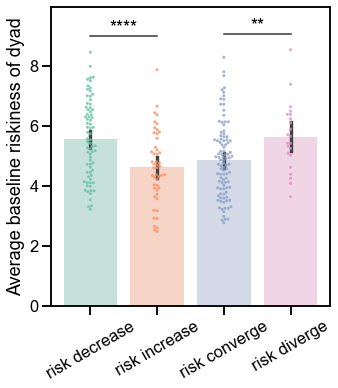

In [47]:

# sns.swarmplot(data = collapsed_g, x='cluster', y='idvDiff', palette='Set2', alpha=0.7)
fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
myswarm(data = collapsed_g, x='cluster', y='individual')
mybar(data = collapsed_g, x='cluster', y='individual')
plt.xticks(rotation=30)
plt.ylabel('Average baseline riskiness of dyad')
plt.xlabel('')
model = smf.ols('individual ~ C(cluster)', data=collapsed_g).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


#annotate?
pairs = [("risk increase", "risk decrease"), ("risk converge", "risk diverge"),]
annotator = Annotator(ax, pairs, data=collapsed_g, x='cluster', y='individual', 
                      order=clusters)
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=True,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()

# if save:
#     plt.savefig(f'../paper_figs/{folder}/avg_risk_by_category_{folder}.png', 
#             bbox_inches='tight', dpi=200)

770
                            OLS Regression Results                            
Dep. Variable:               step_inc   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     36.54
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           3.55e-44
Time:                        16:13:08   Log-Likelihood:                -1145.1
No. Observations:                 770   AIC:                             2306.
Df Residuals:                     762   BIC:                             2343.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

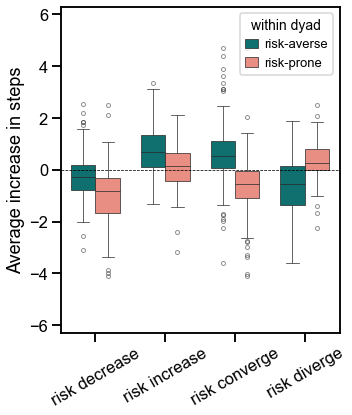

In [48]:
#further: who drives this increase or decrease?

plt.figure(figsize=(5, 6))
test = pd.merge(group_stat, collapsed_g[['room', 'cluster']].drop_duplicates())
print(len(test))
sns.boxplot(data = test, x='cluster', y='step_inc', palette=risk_colors, 
              hue='risky_wpair', order=clusters,
              width=0.7, linewidth=0.7, flierprops=dict(marker='o', markersize=4, alpha=0.5))
# sns.barplot(data = test, x='cluster', y='step_inc', palette='Set2', 
#               hue='risky_wpair', alpha=0.5)
plt.legend(title = 'within dyad', loc='upper right', 
           fontsize=13, title_fontsize=14, handletextpad=0.5,handlelength=1)
# sns.barplot(data = collapsed_g, x='cluster', y='idvDiff', palette='Set2', alpha=0.4)
plt.xticks(rotation=30)
plt.ylabel('Average increase in steps')
plt.axhline(0, color='black', ls='--', lw=0.75)
plt.xlabel('')
plt.ylim([-6.3, 6.3])
if save:
    plt.savefig(f'../paper_figs/{folder}/step_increase_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)
# model = smf.ols('idvDiff ~ C(cluster) + C(risky_wpair)', data=collapsed_g).fit()
# anova_table = sm.stats.anova_lm(model, typ=2)
# print(anova_table)

model = smf.ols('step_inc ~ C(cluster) * C(risky_wpair)', data=test).fit()
print(model.summary())

Cluster risk converge: t-statistic = 3.9415311878297845, p-value = 0.0001510507607695512
Cluster risk decrease: t-statistic = -0.9120395714864717, p-value = 0.3647500114795602
Cluster risk diverge: t-statistic = -0.06839709173946043, p-value = 0.9461166148500929
Cluster risk increase: t-statistic = 7.211011352242674, p-value = 3.4937671277172945e-09


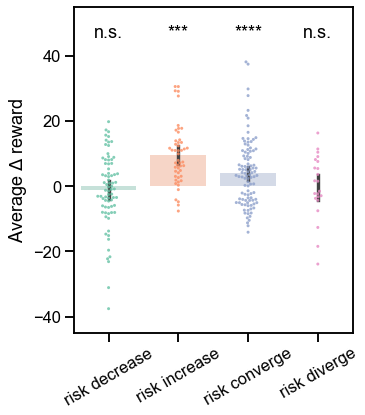

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(5, 6))
collapsed_g['grpIdvRewardDiff']= collapsed_g['jointMoney'] - collapsed_g['reward']
mybar(data = collapsed_g, x='cluster', y='grpIdvRewardDiff')
myswarm(data = collapsed_g, x='cluster', y='grpIdvRewardDiff')
# sns.boxplot(data = collapsed_g, x='cluster', y='grpIdvRewardDiff', palette='Set2')
plt.ylabel('Average $\Delta$ reward')
plt.xticks(rotation=30)
plt.ylim([-45, 55])
plt.xlabel('')


for i, subset in collapsed_g.groupby('cluster'):
    t, p = ss.ttest_1samp(subset['grpIdvRewardDiff'], 0)
    # Print the t-statistic and p-value
    print(f"Cluster {i}: t-statistic = {t}, p-value = {p}")
    #annotate
    idx = collapsed_g['cluster'].unique().tolist().index(i)
    #correct for multiple comparison
    ax.text(x=idx, y=47, s=get_sig(p),  ha='center', va='center')
    # ax.plot([idx-0.25, idx+0.25], [45, 45], color='black', linewidth=1.5)
if save:
    plt.savefig(f'../paper_figs/{folder}/reward_inc_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [50]:
d = pd.merge(group_stat[['subID','room', 'predatorType', 'risky_wpair', 'reward_inc']], 
             collapsed_g[['room', 'predatorType', 'cluster']])
# ss.ttest_ind(d.query('cluster=="risk converge" and risky_wpair=="risk-averse"')['reward_inc'],
#              d.query('cluster=="risk increase" and risky_wpair=="risk-averse"')['reward_inc'])

# ss.ttest_ind(d.query('cluster=="risk converge" and risky_wpair=="risk-prone"')['reward_inc'],
#              d.query('cluster=="risk increase" and risky_wpair=="risk-prone"')['reward_inc'])

In [51]:
# can you just regress risk increase on 

In [52]:
# fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
# sns.barplot(data = collapsed_g, x='cluster', y='jointMoney', 
#             palette='Set2', alpha=0.4, order=clusters)
# sns.swarmplot(data = collapsed_g, x='cluster', y='jointMoney', 
#               palette='Set2', alpha=0.6, order=clusters)
# # sns.boxplot(data = collapsed_g, x='cluster', y='grpIdvRewardDiff', palette='Set2')
# plt.ylabel('dyad reward')
# plt.xticks(rotation=30)
# # plt.ylim([-42, 42])


# #annotate?
# annotator = Annotator(ax, pairs, data=collapsed_g, x='cluster', y='individual', 
#                       order=clusters)
# #set configurations and apply
# annotator.configure(test='t-test_ind', hide_non_significant=True,
#                     comparisons_correction="bonferroni", 
#                     text_format='star', loc='inside', 
#                     line_height =0, text_offset=-1)#for style
# annotator.apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

risk converge vs. risk diverge: t-test independent samples, P_val:8.279e-03 t=-2.685e+00
risk increase vs. risk diverge: t-test independent samples, P_val:1.210e-03 t=-3.376e+00
risk decrease vs. risk diverge: t-test independent samples, P_val:7.965e-01 t=-2.586e-01


(<Axes: ylabel='Average blame asynchrony'>,
  <statannotations.Annotation.Annotation at 0x7fa498b6d850>])

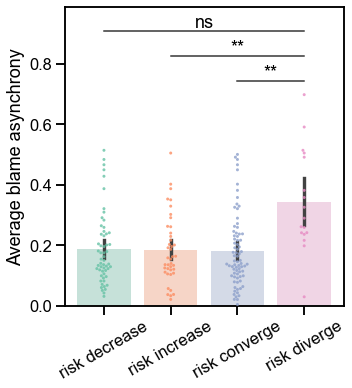

In [53]:
#no difference in sum blame. what about blame async?
fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
test= df_group.copy().query('selfBlame!=-1 and partnerBlame!=-1 and playerID==1') # keep 1 per group
test['blameAsync'] = abs(test['selfBlame'] + test['partnerBlame'] - 1)
test = test.groupby(['room'], as_index=False)['blameAsync'].mean()
collapsed_g2 = pd.merge(test,
                collapsed_g[['room', 'cluster']].drop_duplicates())


mybar(data = collapsed_g2, x='cluster', y='blameAsync')
myswarm(data = collapsed_g2, x='cluster', y='blameAsync')
plt.xticks(rotation=30)
plt.xlabel('')
plt.ylabel('Average blame asynchrony')

#annotate?
pairs = [("risk increase", "risk diverge"), 
         ("risk converge", "risk diverge"),
         ("risk decrease", "risk diverge"), 
        ]
annotator = Annotator(ax, pairs, data=collapsed_g, x='cluster', y='individual', 
                      order=clusters)
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=False,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

risk converge vs. risk diverge: t-test independent samples, P_val:5.484e-09 t=-6.049e+00
risk increase vs. risk diverge: t-test independent samples, P_val:1.898e-06 t=-4.973e+00
risk decrease vs. risk diverge: t-test independent samples, P_val:1.439e-06 t=-4.978e+00


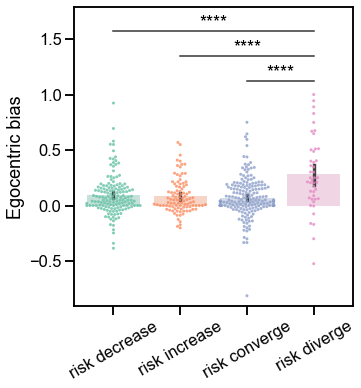

In [54]:
# self-attribution bias difference between clusters
bias_df = df_group.query('selfBlame!=-1').groupby(['attack', 'subID', 'room', 'predatorType'], as_index=False)['selfBlame'].mean()
bias_df = pd.merge(bias_df.query('attack==False'), bias_df.query('attack==True'), on=['subID', 'room', 'predatorType'])
bias_df['bias'] = bias_df['selfBlame_x'] - bias_df['selfBlame_y']
bias_df = pd.merge(bias_df[['subID', 'bias', 'room', 'predatorType']], collapsed_g)
# bias_df = bias_df.groupby(['room', 'cluster', 'predatorType'], as_index=False).mean()


fig, ax = plt.subplots(1, 1, figsize=(5, 5.5))
mybar(data = bias_df, x='cluster', y='bias')
myswarm(data = bias_df, x='cluster', y='bias')
# sns.stripplot(data = bias_df, x='cluster', y='bias', palette='Set2')
plt.xticks(rotation=30)
plt.xlabel('')
plt.ylabel('Egocentric bias')

#annotate?
pairs = [("risk increase", "risk diverge"), 
         ("risk converge", "risk diverge"),
         ("risk decrease", "risk diverge"), 
        #  ("risk increase", "risk converge"), 
        #  ("risk decrease", "risk converge"), 
        ]
annotator = Annotator(ax, pairs, data=bias_df, x='cluster', y='bias', 
                      order=clusters)
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=False,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()

if save:
    plt.savefig(f'../paper_figs/{folder}/blame_bias_by_category_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [55]:
# #idv
# df_idv['player_change'] = df_idv.query('trial>60').groupby(['sub', 'predatorType'])['choice'].shift(-1) -df_idv['choice']
# # sns.lmplot(data=df_cleaned, x='partner_changed_rel', y='player_future_change_rel', scatter=False)
# sns.lineplot(data=df_idv.groupby(['sub', 'choice', 'predatorType'], as_index=False)['player_change'].mean(), 
#              x='choice', y='player_change', hue='predatorType')
# plt.ylim([-6, 6])
# # plt.xlabel('player partner step difference')
# # plt.ylabel('player step change')

In [56]:
#what drives this correlation?
# 

# Fig2 Sharing Responsibility and Reward

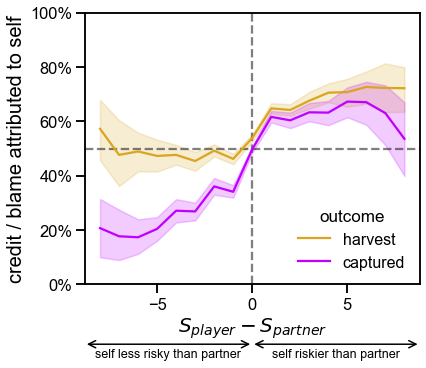

In [57]:
#plot split by step

plt.figure(figsize=(6, 5))
plt.axhline(y=0.5, ls='--', color='black', alpha=0.5)
plt.axvline(x=0, ls='--', color='black', alpha=0.5)
d = df_group.query('selfBlame!=-1').groupby(['subID','player_partner_diff', 'outcome'],
                                             as_index=False)['selfBlame'].mean()

#remove when playerStep=0

d = d.query('player_partner_diff>-9 and player_partner_diff<9')
#for plotting
# d['outcome'] = d['attack'].apply(lambda x: 'win' if x==False else 'lose')
sns.lineplot(data=d, x='player_partner_diff', y='selfBlame', hue='outcome', 
            #  palette=['green', 'red'] #'fuchsia'
            palette = outcome_colors
            )
plt.xlabel('$S_{player} - S_{partner}$',fontsize=20)
plt.ylabel('credit / blame attributed to self', fontsize=20)
plt.ylim([0, 1])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
#plt.legend().remove()
plt.legend(loc='lower right',
           title='outcome', frameon=False,fontsize=16, title_fontsize=17)

# add arrows below
plt.annotate('', xy=(0, -0.22), xytext=(0.5, -0.22), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('', xy=(0.5, -0.22), xytext=(1, -0.22), 
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', lw=1.5))
plt.annotate('self less risky than partner', xy=(0.03, -0.27), 
             xycoords='axes fraction', ha='left', fontsize=12.5)
plt.annotate('self riskier than partner', xy=(0.56, -0.27), 
             xycoords='axes fraction', ha='left', fontsize=12.5)
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [58]:
#for each subject, compare blame vs credit when self behind?

In [59]:
reg_data = df_group.query('selfBlame!=-1')
reg_data = reg_data[['subID', 'player_partner_diff', 'outcome', 'selfBlame', 'trial', 'predatorType']].dropna()
# mean center blame
reg_data['selfBlame'] = reg_data['selfBlame'] - 0.5
blame_model = smf.mixedlm(formula='selfBlame ~ player_partner_diff * outcome', 
                    data=reg_data, groups = reg_data['subID'],
                    re_formula="~ player_partner_diff * outcome"
                    ).fit()

print(blame_model.summary())
with open(f'../model_fits/regs/blame_reg_summary_{folder}.txt', "w") as f:
    f.write(blame_model.summary().as_text())

                                   Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  selfBlame
No. Observations:                    14545                    Method:                              REML     
No. Groups:                          250                      Scale:                               0.0226   
Min. group size:                     37                       Log-Likelihood:                      5831.6162
Max. group size:                     60                       Converged:                           Yes      
Mean group size:                     58.2                                                                   
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

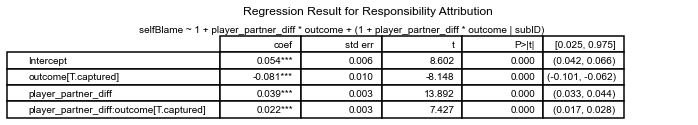

In [60]:
blame_formula = 'selfBlame ~ 1 + player_partner_diff * outcome + (1 + player_partner_diff * outcome | subID)'
title = "Regression Result for Responsibility Attribution"
save_reg_to_table(blame_model, 4, blame_formula, title)

blame difference: r=3.5849575685700468, p=0.00040589514999238914
blame asynchrony: r=-1.1158799915536664, p=0.26555355949757364


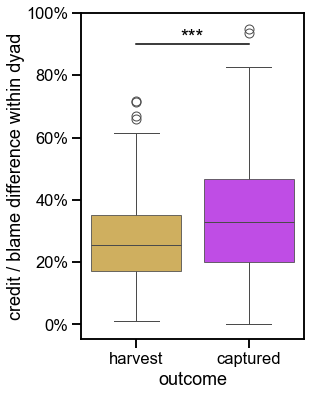

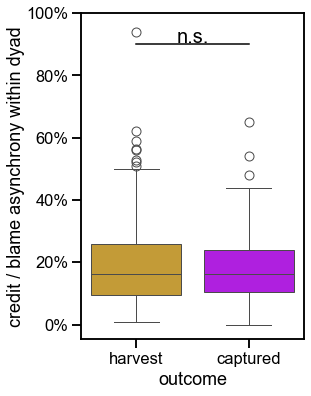

In [61]:
#bar plot of blame diff of each individual?
plt.figure(figsize=(4, 6))
df_group['blame_diff'] = df_group.groupby(['room', 'trial', 'predatorType'], as_index=False)['selfBlame'].diff()
df_group['blame_diff'] = np.abs(df_group['blame_diff'])
d = df_group.groupby(['outcome', 'room'], as_index=False)['blame_diff'].mean()
#more disagreement when attack happens. why?
sns.boxplot(data = d, x='outcome', y='blame_diff', palette=outcome_colors, 
            boxprops=dict(alpha=.8))
# plt.xticks([0, 1], ['win', 'lose'])
plt.ylim(top=1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
# plt.xlabel('outcome')
plt.ylabel('credit / blame difference within dyad', labelpad=1)
# run a independent t-test
r, p = ss.ttest_ind(d.query('outcome=="captured"')['blame_diff'], 
                    d.query('outcome=="harvest"')['blame_diff'])
print(f"blame difference: r={r}, p={p}")
#people are more likely to share reward than losses
sig = get_sig(p)
plt.text(0.5, 0.89, sig, ha='center', va='bottom', fontsize=20)
plt.plot([0, 0, 1, 1], [0.9, 0.9, 0.9, 0.9], lw=1.5, color='black')
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_diff_{folder}.png', 
            bbox_inches='tight', dpi=200)


#bar plot of blame async of each dyad?
plt.figure(figsize=(4, 6))
test= df_group.copy()
test = test.dropna(subset=['partnerBlame']).query(
    'selfBlame!=-1 and partnerBlame!=-1')
test['blameAsync'] = abs(test['selfBlame'] + test['partnerBlame'] - 1)
d = test.query('playerID==0').groupby(['room', 'outcome'], as_index=False)['blameAsync'].mean()
#more disagreement when attack happens. why?
sns.boxplot(data = d, x='outcome', y='blameAsync', palette = outcome_colors)
# plt.xticks([0, 1], ['win', 'lose'])
plt.ylim(top=1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0%', '20%', '40%', '60%', '80%', '100%'])
# plt.xlabel('outcome')
plt.ylabel('credit / blame asynchrony within dyad', labelpad=1)
#run a paired t-test
r, p = ss.ttest_ind(d.query('outcome=="captured"')['blameAsync'], 
                    d.query('outcome=="harvest"')['blameAsync'])
print(f"blame asynchrony: r={r}, p={p}")
#people are more likely to share reward than losses
#people are more likely to share reward than losses
# Annotate the plot with significance if p-value < 0.05
sig = get_sig(p)
plt.text(0.5, 0.89, sig, ha='center', va='bottom', fontsize=20)
plt.plot([0, 0, 1, 1], [0.9, 0.9, 0.9, 0.9], lw=1.5, color='black')

In [62]:
#count the max number of attack trials for each subject
# l= df_group.groupby(['sub', 'room'], as_index=False)['attack_count'].max()
# #select all the noattack trials to match the number of attack trials for each subject
# merged_df = pd.merge(df_group[['sub', 'room', 'noattack_count', 'selfBlame', 'blame_diff']], l)
# filtered_attack = merged_df[merged_df['noattack_count'] <= merged_df['attack_count']]
# #merge with all attack trials
# filtered_trials = pd.concat([filtered_attack.drop('attack_count', axis=1), df_group.query('attack==1')[['sub', 'room', 'selfBlame', 'attack', 'blame_diff', 'attack_count']]])
# filtered_trials['attack'] = filtered_trials['attack'].fillna(False)
# # #calculate the mean self blame for each subject for selected noattack trials
# # filtered_attack['blame_diff'] = filtered_attack.groupby('room', as_index=False)['selfBlame'].diff()
# # #calculate the mean self blame for each subject for attack trials
# # meanblame_attack['blame_diff'] = df_group.query('attack==1').groupby('room', as_index=False)['selfBlame'].diff()
# # #compare the means
# # d = pd.merge(meanblame_attack, meanblame_noattack, on='room')
# # sns.regplot(data=d, x='selfBlame_x', y='selfBlame_y')
# print(len(filtered_trials))

In [63]:
# plt.axhline(y=0.5, ls='--', color='black', alpha=0.5)
# plt.axvline(x=0, ls='--', color='black', alpha=0.5)
# sns.lineplot(data=g.groupby(['sub', 'partner_diff', 'attack'], as_index=False)['selfBlame'].mean(),
#              x='partner_diff', y='selfBlame', label='partner', color='salmon')
# sns.lineplot(data=g.groupby(['sub', 'player_diff', 'attack'], as_index=False)['selfBlame'].mean(),
#              x='player_diff', y='selfBlame', label='player', color='teal')
# plt.xlabel('Step (t) - Step (t-1)')
# plt.ylabel('player self-blame')
# plt.legend(title='data type', loc='lower center')
# plt.ylim([0, 1])



# plt.figure()
# plt.axhline(y=0.5, ls='--', color='black', alpha=0.5)
# plt.axvline(x=0, ls='--', color='black', alpha=0.5)
# sns.lineplot(data=g2.groupby(['sub', 'partner_diff', 'attack'], as_index=False)['playerKeep'].mean(),
#              x='partner_diff', y='playerKeep', label='partner', color='salmon')
# sns.lineplot(data=g2.groupby(['sub', 'player_diff', 'attack'], as_index=False)['playerKeep'].mean(),
#              x='player_diff', y='playerKeep', label='player', color='teal')
# plt.xlabel('Step (t) - Step (t-1)')
# plt.ylabel('player keeps')
# plt.legend(title='data type', loc='lower center')
# plt.ylim([0, 1])

In [64]:
# df_group['future_step_change'] = df_group.groupby(['subID', 'predatorType'])['playerStep'].shift(-1) - df_group['playerStep']
# test = df_group.query('selfBlame!=-1').copy()
# test['player_partner_diff'] =  np.sign(test['player_partner_diff'])  # Convert to binary
# # test['selfBlame'] = np.sign(test['selfBlame'] - 0.5)  # Convert blame to -1, 0, 1
# test['compromise'] =  np.sign(test['future_step_change']) == -np.sign(test['player_partner_diff'])  # Convert to binary
# # test['compromise'] =  - test['future_step_change'] / test['player_partner_diff']

# test=test.groupby(['predatorType', 'selfBlame', 'attack', 'sub'], as_index=False)['compromise'].mean()
# test = pd.merge(test, group_stat[['sub', 'risky_wpair', 'predatorType']])
# sns.lineplot(data = test, hue='attack', y='compromise', x='selfBlame', style = 'risky_wpair', palette=outcome_colors)
# # plt.legend(loc='upper center', title='attack')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='attack')


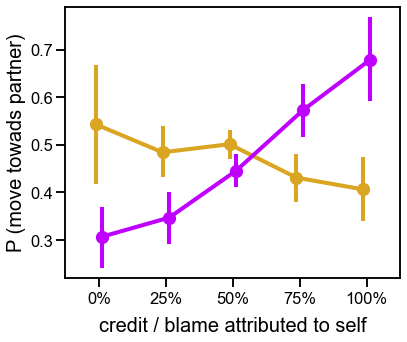

In [65]:
#plot step change vs blame, separate by attack
plt.figure(figsize=(6, 5))
df_group['future_step_change'] = df_group.groupby(['subID', 'predatorType'])['playerStep'].shift(-1) - df_group['playerStep']
df_group['future_step_rt'] = df_group.groupby(['subID', 'predatorType'])['step_rt'].shift(-1)
test = df_group.query('selfBlame!=-1').copy()
#test['player_partner_diff'] =  np.sign(test['player_partner_diff'])  # Convert to binary
# test['selfBlame'] = np.sign(test['selfBlame'] - 0.5)  # Convert blame to -1, 0, 1
test['compromise'] =  np.sign(test['future_step_change']) == -np.sign(test['player_partner_diff'])  # Convert to binary
# test['compromise'] =  - test['future_step_change'] / test['player_partner_diff']
test['outcome'] = test['attack'].apply(lambda x: 'win' if x==False else 'lose')
d=test.groupby(['subID', 'selfBlame', 'outcome'], as_index=False)['compromise'].mean()
sns.pointplot(data = d, hue='outcome', y='compromise', x='selfBlame', palette=outcome_palette, dodge=0.1)
# plt.legend(loc='upper center', title='outcome')
plt.legend().remove()
# plt.legend().remove()
plt.ylabel('P (move towads partner)', fontsize=20)
# plt.ylim([0, 1])
plt.xlabel('credit / blame attributed to self', labelpad=10, fontsize=20)
# plt.xticks([0, 0.25, 0.5, 0.75, 1], ['0%', '25%', '50%', '75%', '100%'])
plt.xticks([0, 1, 2, 3, 4], ['0%', '25%', '50%', '75%', '100%'])
if save:
    plt.savefig(f'../paper_figs/{folder}/compromise_blame_{folder}.png',
                bbox_inches='tight', dpi=200)



# Fig3 model comparison

In [66]:
def read_model_df(mname, fname, folder = folder):
    if fname != '':
        fname = '_' + fname
    if folder == "conf":
        p7 = pd.read_csv(f'../model_fits/rl_rep2/{mname}{fname}.csv')
        p7['subID']= p7['subID'] + 400

        df = pd.concat([p7, pd.read_csv(f"../model_fits/rl_conf/{mname}_conf{fname}.csv")])
    else:
        df = pd.read_csv(f"../model_fits/rl_expl/{mname}{fname}.csv")
        
    return df

In [67]:
def mybic(mse, k, N = 178): #176 trials becuase we ignored the first trial for each predator
    return k * np.log(N) + N * np.log(mse / N)

def myaic(mse, k, N = 178):
    return k * 2 + N * np.log(mse / N)

# def mybic(mse, k, N = 178): #176 trials becuase we ignored the first trial for each predator
#     return k * np.log(N) + N * (np.log(2 * np.pi) + mse)

# def myaic(mse, k, N = 178):
#     return k * 2 + N * (np.log(2 * np.pi) + mse)

In [68]:
m1_list = [
        # "peppgFull_econ_Theta_mse", 
        "peppgFull_econ_ThetaGamma", 
        # "valueppgFull_econ_Theta_mse", 
        # "valueppgFull_econ_ThetaGamma_mse"
        ]
m2_list = ["arbWeight", "updateTheta", "asIfIdv"] #"deltaWeight",

all_params_df = pd.DataFrame()
for mymodel in m1_list:
    for mymodel2 in m2_list:
        try:
            params_df = read_model_df(f"{mymodel}_{mymodel2}", '')
            params_df['model_name'] = mymodel2
            params_df = params_df.rename({'nll':'mse'}, axis=1)
            k = 4 if mymodel2!="asIfIdv" else (3 if mymodel2!="deltaWeight" else 5)
            params_df['bic'] = params_df['mse'].apply(lambda x: mybic(x, k))
            params_df['aic'] = params_df['mse'].apply(lambda x: myaic(x, k))
            all_params_df = pd.concat([all_params_df, params_df])
        except:
            pass

print(all_params_df['model_name'].unique())
print(len(all_params_df['subID'].unique()))
# if min(all_params_df['subID'])==1:
#     all_params_df['subID'] = all_params_df['subID'] - 1
# print(f"{len(params_df.subID.unique())} subs with avg nll = {np.mean(params_df.loc[params_df.nll!=np.inf]['nll'])}")
all_params_df.head()




['arbWeight' 'updateTheta' 'asIfIdv']
250


,subID,alpha,theta,gamma,w,mse,model_name,bic,aic
0,18,0.00,0.68,0.08,0.57,1000.0,arbWeight,327.950102,315.222968
1,14,0.95,0.88,0.49,0.00,535.0,arbWeight,216.613143,203.886009
2,4,0.12,0.45,0.70,0.28,413.0,arbWeight,170.543334,157.816200
3,0,0.50,0.86,0.77,0.59,52.0,arbWeight,-198.308956,-211.036090
4,2,0.30,0.98,0.75,0.52,219.0,arbWeight,57.624430,44.897296


In [69]:
df_idv.columns

Index(['attack', 'attackProb', 'attackRange', 'choice', 'currProb',
       'predatorType', 'reward', 'round', 'rt', 'totMoney', 'trial', 'subID',
       'predator', 'num_encounter'],
      dtype='object')

In [70]:
#make sure the order matches!
model_names = ['Other-regarding\npreference\n', 'Social\ninfluence', 'As-if\nindividual']

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

arbWeight vs. updateTheta: t-test paired samples, P_val:8.661e-06 t=-4.543e+00
updateTheta vs. asIfIdv: t-test paired samples, P_val:6.267e-07 t=-5.115e+00
arbWeight vs. asIfIdv: t-test paired samples, P_val:1.274e-09 t=-6.309e+00


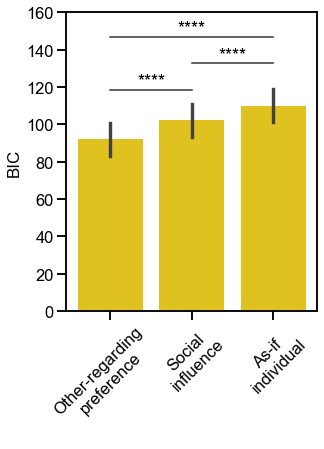

In [71]:
sns.set_context("talk")
fig, ax = plt.subplots(1, 1, figsize=(4.5, 5.5))
sns.barplot(data = all_params_df, x='model_name', y='bic', color='gold',
            errorbar="se", 
            # s=3, alpha=0.8, 
            order = m2_list)

#set xticks
plt.xticks(np.arange(len(model_names)), model_names, rotation=45)
plt.xlabel('')
plt.ylabel('BIC', fontsize=17)

# #print significance
# print(ss.ttest_rel(all_params_df.query('model_name=="arbWeight"')['bic'],
#              all_params_df.query('model_name=="stopLearning"')['bic']))
# print(ss.ttest_rel(all_params_df.query('model_name=="updateTheta"')['bic'],
#              all_params_df.query('model_name=="asIfIdv"')['bic']))

#add annotation
# pairs=[(0, 1), (0, 2), (1, 2)]
pairs = [(m2_list[i], m2_list[j]) for i in range(len(m2_list)) for j in range(i)]
# pairs = [(m2_list[0], m2_list[1]), (m2_list[0], m2_list[2])]
annotator = Annotator(ax, pairs, data=all_params_df, x='model_name', y='bic', 
                      order=m2_list)
#set configurations and apply
annotator.configure(test='t-test_paired', text_format='star', loc='inside',
                    line_height =0, text_offset=-1, hide_non_significant=False)#for style
annotator.apply_and_annotate()

# plt.ylim([0, 200])
# plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/bic_{folder}.png', 
                bbox_inches='tight', dpi=200)

In [72]:
best_models = pd.merge(all_params_df, all_params_df.groupby('subID', as_index=False)['bic'].min())
model_of_interest = "arbWeight"
# model_of_interest = "asIfIdv"
# model_of_interest = "updateTheta"

total_subjects = len(all_params_df['subID'].unique())
proportion = len(best_models.query('model_name==@model_of_interest')) / total_subjects

print(f"Proportion of subjects fit best by {model_of_interest}: {proportion:.2f}")


Proportion of subjects fit best by arbWeight: 0.48


In [73]:
#look at people who fit best by asIfIdv:

# s = best_models.query('model_name==@model_of_interest')['subID'].unique()
# rt_model = smf.mixedlm('log_step_rt ~ abs_self_pred_diff + playerStep', 
#                     data = rt_reg.query('subID in @s'),
#                     groups = rt_reg.query('subID in @s')['sub'],
#                     re_formula = '~ abs_self_pred_diff + playerStep'
#                 ).fit(reml=False, method="lbfgs", maxiter=2000)
# print(rt_model.summary())
# df_group.query('subID in @s and step_rt<8').groupby(['subID', 'predatorType'])['playerStep'].var()

In [74]:
# fig, ax = plt.subplots(1, 1, figsize=(4.5, 5.5))
# sns.barplot(best_models.groupby(['model_name'])['subID'].count() / total_subjects, color='gold')
# #set xticks
# # plt.xticks(np.arange(len(model_names)), model_names, rotation=45)
# plt.xlabel('')
# plt.ylabel('percentage of subjects \nbest fit by each model')


In [75]:
mymodel = "peppgFull_econ_ThetaGamma"
mymodel2 = "arbWeight"
mname = f"{mymodel}_{mymodel2}"

GENRULE, CHOICERULE = mymodel.split("_")[0:2]
print([GENRULE, CHOICERULE])

params_df = read_model_df(mname, '', folder)

print(len(params_df))
params_df.head()

['peppgFull', 'econ']
250


,subID,alpha,theta,gamma,w,nll
0,18,0.00,0.68,0.08,0.57,1000.0
1,14,0.95,0.88,0.49,0.00,535.0
2,4,0.12,0.45,0.70,0.28,413.0
3,0,0.50,0.86,0.77,0.59,52.0
4,2,0.30,0.98,0.75,0.52,219.0


PearsonRResult(statistic=0.023997891480132295, pvalue=0.705733121398765)

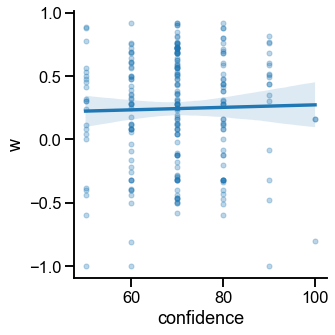

In [76]:
# check confidence
cfd = pd.merge(df_group.groupby(['subID'], as_index=False)[['confidence']].mean(), params_df).dropna()
# cfd = pd.merge(cfd, df_idv.groupby(['subID'], as_index=False)[['reward']].mean())
sns.lmplot(data = cfd, x='confidence', y='w', scatter_kws={'alpha':0.3, 's':25})
ss.pearsonr(cfd['confidence'], cfd['w'])


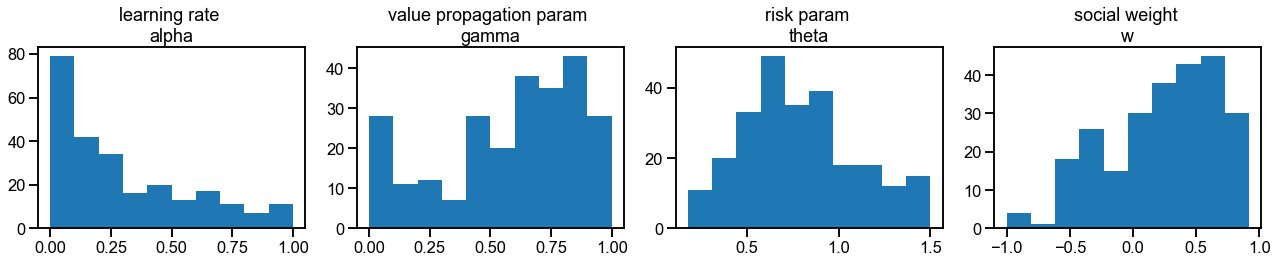

In [77]:
fig, axes = plt.subplots(1,4,figsize=(18,4))
axes[0].hist(params_df['alpha'])
axes[1].hist(params_df['gamma'])
axes[2].hist(params_df['theta'])
axes[3].hist(params_df['w'])
# axes[4].hist(params_df['delta'])
axes[0].set_title('learning rate \nalpha')
axes[1].set_title('value propagation param \ngamma')
axes[2].set_title('risk param \ntheta')
axes[3].set_title('social weight \nw')
plt.tight_layout()


          $\alpha$  $\gamma$  $\theta$     w
$\alpha$      1.00      0.00      0.17  0.09
$\gamma$      0.00      1.00      0.05 -0.04
$\theta$      0.17      0.05      1.00 -0.14
w             0.09     -0.04     -0.14  1.00


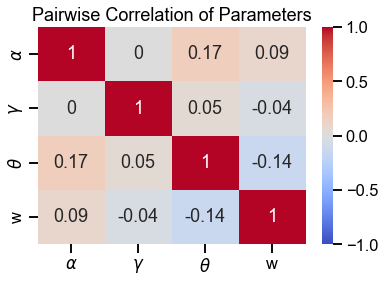

In [78]:
param_cols = ['alpha', 'gamma', 'theta', 'w']
params = params_df[param_cols]
params = params.rename({'alpha':r"$\alpha$", 
                        'gamma':r"$\gamma$",
                        'theta':r"$\theta$",
                        }, axis=1)

# Compute pairwise Pearson correlations
corr_matrix = params.corr(method='pearson')
corr_matrix = corr_matrix.round(2)
print(corr_matrix)

# Optional: visualize with seaborn heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pairwise Correlation of Parameters")
plt.show()


# # Create pairwise scatterplots
# # Create a custom PairGrid to mask upper triangle
# g = sns.PairGrid(params, corner=True)  # corner=True shows only lower triangle

# # Add scatterplot and regression line to lower triangle
# g.map_lower(sns.regplot, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})

# # Optional: add histograms on diagonal
# g.map_diag(sns.histplot, kde=True)

          25%  50% (Median)     75%
alpha  0.0800          0.21  0.4700
gamma  0.4225          0.67  0.8100
theta  0.5625          0.76  0.9775
w     -0.0800          0.30  0.5975


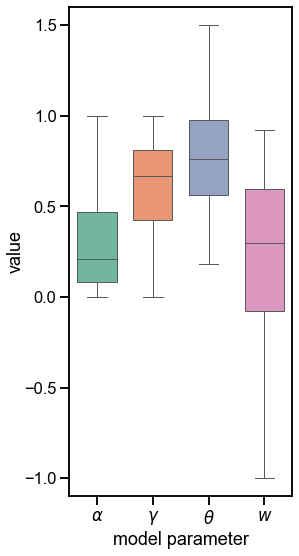

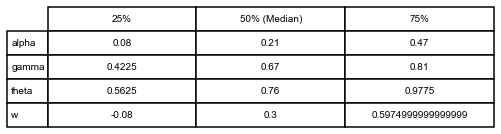

In [79]:
#box plot
plt.figure(figsize=(4, 9))
plt.ylim([-1.1, 1.6])
# t = params_df[['alpha_w', 'alpha_l', 'theta', 'w', 'subID']].melt(id_vars='subID')
t = params_df[['alpha', 'gamma', 'theta', 'w', 'subID']].melt(id_vars='subID')
sns.boxplot(data = t, x='variable', y='value', palette= sns.color_palette("Set2"), width=0.7)
plt.xticks(range(4), [r'$\alpha$', r'$\gamma$', r'$\theta$', r'$w$'])
plt.xlabel('model parameter')
plt.ylabel('value', labelpad=-1)

plt.savefig(f'../paper_figs/{folder}/params_dist_{folder}.png', 
            bbox_inches='tight', dpi=200)



# print summary statcistics
summary = params_df[['alpha', 'gamma', 'theta', 'w']].quantile([0.25, 0.5, 0.75]).T
summary.columns = ['25%', '50% (Median)', '75%']
# Step 2: Create table as plot
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')  # Hide axes

table = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)

table.scale(1, 2)  # Scale table cells
table.auto_set_font_size(False)
table.set_fontsize(10)
print(summary)


[250, -0.3891209708837896, 1.8329923505566345e-10]
[250, 0.6851049933744499, 5.506512086247811e-36]
[250, 0.30085619858344914, 1.2606988188934978e-06]


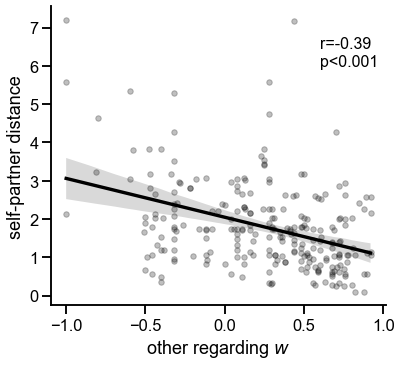

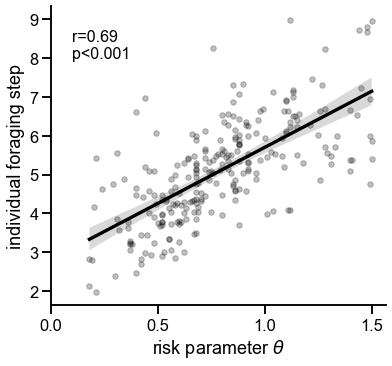

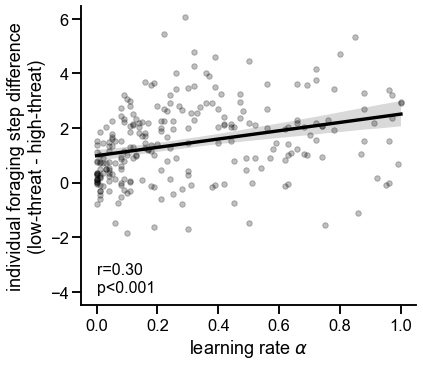

In [80]:
scatter_kws = {'alpha':0.25, 's':30, 'color':'black'}

def plot_param_correlation(d, xvar, yvar, xlabel, ylabel, xloc, yloc):
    d = pd.merge(params_df, d)

    plt.figure(figsize=(6, 5.5))
    sns.regplot(data=d, x=xvar, y=yvar, 
            scatter_kws = scatter_kws, line_kws={'color': 'black'},
            )
    r, p = ss.pearsonr(d[xvar], d[yvar])
    print([len(d), r, p])
    
    if p<0.001:
        p = '<0.001'
    else:
        p = round(p, 3)
    if xvar =='theta':
        plt.xlim(left=xloc-0.1)
    if xvar=='alpha':
        plt.ylim(bottom=yloc-0.5)

    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    sns.despine()
    plt.text(
        xloc, yloc,
        f'r={r:.2f}\np{p}',
        fontsize=16
    )
    if save:
        plt.savefig(f'../paper_figs/{folder}/supp_correlation_{xvar}_{folder}.png', 
            bbox_inches='tight', dpi=200)


# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#is convergence correlated with w? larger weight on partner pref -> more convergence
d = df_group.groupby('subID', as_index=False
        )['player_partner_diff'].apply(lambda x: np.mean(np.absolute(x)))
plot_param_correlation(d, 'w', 'player_partner_diff', 'other regarding $w$', 'self-partner distance', 0.6, 6)

#higher prelec param -> underweighting of small probability -> risk-averse
#higher econ risk param ->risky
d = df_idv.query('trial>60').groupby(['subID'], as_index=False)['choice'].mean()
plot_param_correlation(d, 'theta', 'choice', 'risk parameter ' + r'$\theta$', 'individual foraging step', 0.1, 8)


#can different model predict different choice patterns towards different predators?
d = df_idv.query('trial>60').groupby(['subID', 'predatorType'], as_index=False)['choice'].mean()
d = pd.merge(d.query('predatorType==0'), d.query('predatorType==1'), on='subID')
d['choice_diff'] = d['choice_x'] - d['choice_y']
#correlate learning rates with differences in choice between predators
# sns.set_context('talk')
plot_param_correlation(d, 'alpha', 'choice_diff', 'learning rate '+r'$\alpha$', 'individual foraging step difference\n(low-threat - high-threat)', 0, -4)




peppgFull_econ_ThetaGamma_arbWeight
250


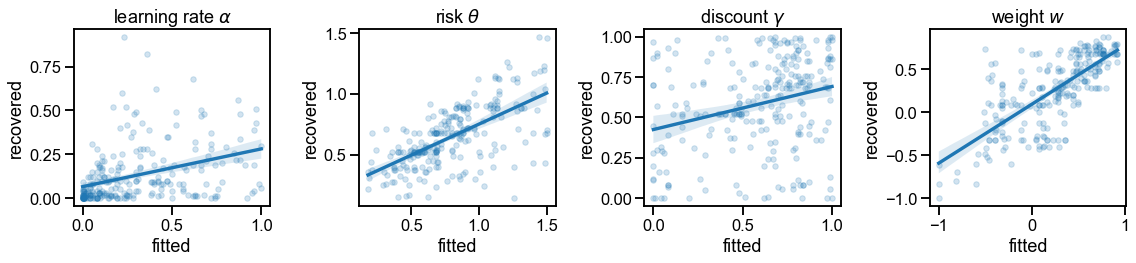

In [81]:
#show recovery
# mymodel = "peppgFull_econ_ThetaGamma"
# mymodel2 = "arbWeight"

print(mname)

rec_df = read_model_df(mname, 'recovery')
m = pd.merge(params_df, rec_df, on=['subID'])
# # #if fit by sub:
# rec_df['subID'] = rec_df['subID']-1
# rec_df.head()
m.head()

sns.set_context('talk')
m['gamma2_x'] = m['gamma_x'] * m['alpha_x']
m['gamma2_y'] = m['gamma_y'] * m['alpha_y']
print(len(m))
col_names = {'alpha':r'learning rate $\alpha$',
             'theta': r'risk $\theta$',
             'gamma': r'discount $\gamma$',
             'w':r'weight $w$'}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(['alpha', 'theta', 'gamma', 'w']):
    sns.regplot(data=m, x=col+'_x', y=col+'_y', ax=axes[i], scatter_kws={'s':30, 'alpha':0.2})
    # axes[i].plot([axes[i].get_xlim()[0], axes[i].get_xlim()[1]], [axes[i].get_ylim()[0], axes[i].get_ylim()[1]], 
    #              ls='--', lw=1.5)
    #add title
    # col = re.sub(r'\d+', '', col)
    # axes[i].set_title(f"$\{col}$" if col!='w' else f"${col}$")
    axes[i].set_title(col_names[col])
    axes[i].set_xlabel('fitted')
    axes[i].set_ylabel('recovered')
    ss.pearsonr(m['w_x'], m['w_y'])

    
plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/supp_recovery_{mymodel}_{mymodel2}_{folder}.png', 
                bbox_inches='tight', dpi=200)

In [82]:
# show simulations
def read_simulations(folder, sim_type='partial'):
    sim_df_grp = read_model_df(mname, f'sim_group_{sim_type}')
    sim_df_idv = read_model_df(mname, f'sim_idv_{sim_type}')


    assert min(sim_df_grp['subID'])==0
    sim_df_grp = pd.merge(sim_df_grp.query('k==1'), df_group).sort_values(by=['subID', 'trial']).reset_index(drop=True)
    sim_g = sim_df_grp.groupby(['subID', 'predatorType'], as_index=False)[['playerStep', 'sim_playerStep']].mean() 

    sim_df_idv = pd.merge(sim_df_idv.query('k==1'), df_idv).sort_values(by=['subID', 'trial']).reset_index(drop=True)
    sim_i = sim_df_idv.groupby(['subID', 'predatorType'], as_index=False)[['choice', 'sim_choice']].mean()

    return sim_g, sim_i

In [83]:
sim_g, sim_i = read_simulations(folder)

In [84]:
print(len(sim_g.subID.unique()))

250


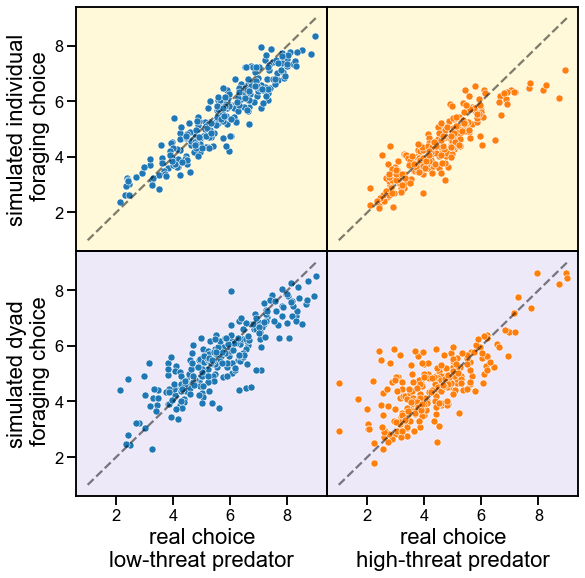

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True, sharey=True)
colors=sns.color_palette()
for i in [0, 1]: #fore each predator
    axes[0, i].plot([1, 9], [1, 9], ls='--', color='black', alpha=0.5)
    axes[1, i].plot([1, 9], [1, 9], ls='--', color='black', alpha=0.5)
    #idv
    sns.scatterplot(x=sim_i.query('predatorType==@i')['choice'], 
                    y=sim_i.query('predatorType==@i')['sim_choice'], 
                    ax=axes[0, i], color=colors[i], s=50)
    #group
    sns.scatterplot(x=sim_g.query('predatorType==@i')['playerStep'], 
                    y=sim_g.query('predatorType==@i')['sim_playerStep'], 
                    ax=axes[1, i], color=colors[i], s=50)

    axes[0, i].set_facecolor((255/255, 215/255, 0/255, 0.15))
    axes[1, i].set_facecolor((147/255, 112/255, 219/255, 0.15))
    axes[i, 1].tick_params(left=False)
    axes[0, i].tick_params(bottom=False)
plt.subplots_adjust(wspace=0, hspace=0)
# axes[0, 0].set_title('safe predator')
# axes[0, 1].set_title('dangerous predator')

axes[0, 0].set_ylabel('simulated individual\n foraging choice', fontsize=22)
axes[1, 0].set_ylabel('simulated dyad\n foraging choice', fontsize=22)

axes[1, 0].set_xlabel("real choice\nlow-threat predator", fontsize=22)
axes[1, 1].set_xlabel("real choice\nhigh-threat predator", fontsize=22)
axes[1, 0].set_xticks([2, 4, 6, 8])
axes[1, 1].set_xticks([2, 4, 6, 8])
if save: 
    plt.savefig(f'../paper_figs/{folder}/simulations_{folder}.png',
            bbox_inches='tight', dpi=200)

In [86]:
# mname_alt = f"{mymodel}_asIfIdv"
# mname_alt = f"{mymodel}_updateTheta"
mname_alt = f"{mymodel}_arbWeight"

# replicate regression
sim_df_grp = read_model_df(mname_alt,'sim_group_full')
sim_df_idv = read_model_df(mname_alt,'sim_idv_full')
sim_df_idv = pd.merge(sim_df_idv, df_idv[['subID', 'trial', 'predatorType']])

sim_df_grp = pd.merge(sim_df_grp, df_group, how='right').sort_values(by=['subID', 'trial']).reset_index(drop=True)
sim_df_grp["sim_playerStep"] = sim_df_grp["sim_playerStep"].fillna(sim_df_grp["playerStep"])
sim_df_grp["sim_attack"] = sim_df_grp["sim_attack"].fillna(sim_df_grp["attack"])
sim_df_grp["k"] = sim_df_grp["k"].fillna(1)
sim_df_grp['sim_player_change'] = sim_df_grp.groupby(['subID', 'predatorType'])['sim_playerStep'].shift(-1) - sim_df_grp['sim_playerStep']
sim_df_grp['sim_player_partner_diff'] = sim_df_grp['sim_playerStep'] - sim_df_grp['partnerStep']
sim_df_grp['sim_attack'] = sim_df_grp['sim_attack'].astype(bool)
sim_df_grp['sim_avgMoney'] = sim_df_grp.apply(lambda row: -10 if row['sim_attack']==1 else np.ceil((row['sim_playerStep'] + row['partnerStep']) / 2) **2, axis=1)

In [87]:
# df_group = df_group.sort_values(by=['subID', 'trial'])
# df_group['player_change'] = df_group.groupby(['subID', 'predatorType'])['playerStep'].shift(-1) - df_group['playerStep']
def plot_stepchange_heatmap(df_group, sim='sim_'):
    pivot_df = df_group.query('partnerStep>0 and trial<30 and playerStep>0').groupby(['subID', 'partnerStep', f'{sim}playerStep'], as_index=False)[f'{sim}player_change'].mean()
    pivot_df = pivot_df.pivot_table(
        index="partnerStep",            # y-axis
        columns=f'{sim}playerStep',       # x-axis
        values=f'{sim}player_change',     # cell values
        aggfunc="mean",                 # or "median", "sum", etc.
        fill_value=np.nan,              # or 0 if you prefer
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(pivot_df, annot=False, cmap="coolwarm", 
                vmin=-3.5, vmax=3.5, 
                cbar_kws={'label': f'{sim}player change'})
    plt.xlabel("playerStep")
    plt.ylabel("partnerStep")
    # plt.title("Heatmap of player step change")
    plt.tight_layout()
    plt.show()

In [88]:
# plot_stepchange_heatmap(df_group, sim='')

In [89]:
# can you get the same regression result with simulated data?

sim_df_grp['sim_ms_playerStep'] = sim_df_grp['sim_playerStep'] - 4.5
df_change_sim_reg = sim_df_grp.query('trial<30').dropna() #remove first and last trial and auto choices

print(len(df_change_sim_reg['subID'].unique()))
change_model_sim = smf.mixedlm('sim_player_change ~ sim_ms_playerStep + sim_player_partner_diff * sim_attack', 
                    data = df_change_sim_reg,
                    groups = df_change_sim_reg['subID'],
                    re_formula = '~ sim_ms_playerStep + sim_player_partner_diff * sim_attack'
                ).fit(reml=False, maxiter=2000)
print(change_model_sim.summary())

# with open(f'../paper_figs/{folder}/change_reg_summary_{mname_alt}_{folder}.txt', "w") as f:
#     f.write(change_model_sim.summary().as_text())

125


                                       Mixed Linear Model Regression Results
Model:                              MixedLM                  Dependent Variable:                  sim_player_change
No. Observations:                   7240                     Method:                              ML               
No. Groups:                         125                      Scale:                               2.5182           
Min. group size:                    48                       Log-Likelihood:                      -14354.6893      
Max. group size:                    58                       Converged:                           Yes              
Mean group size:                    57.9                                                                           
-------------------------------------------------------------------------------------------------------------------
                                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.

250 subjects
median w: 0.3
t = -2.701980981108399, p = 0.007368588856304605


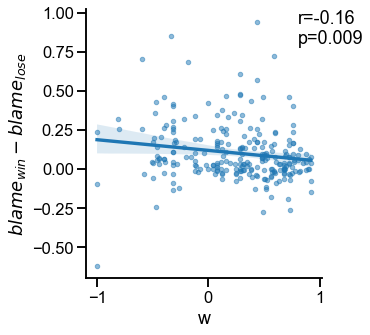

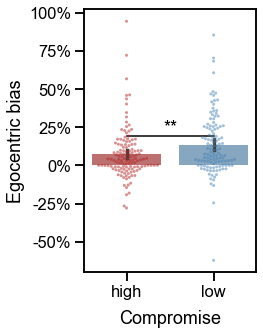

In [90]:
sns.set_context('talk')
compromise_colors = ['firebrick', 'steelblue'] #high, los

#use theta, w
t = df_group.query('step_rt<8 and selfBlame>-1').groupby(['subID', 'room', 'attack'], as_index=False)['selfBlame'].mean()
t = pd.merge(t.query('attack==False'), t.query('attack==True'), on=['subID', 'room'])
t['blame_diff'] = t['selfBlame_x'] - t['selfBlame_y'] #attack_false - attack_win
merged = pd.merge(params_df, t)
print(f"{len(merged)} subjects")

# get riskyiness within dyad through theta
merged = pd.merge(merged.groupby(['room'], as_index=False)['theta'].mean().rename({'theta':'mean_theta'}, axis=1), 
                  merged, how='right')
merged['risky_wpair'] = merged.apply(lambda x:'higher' if x['theta']>x['mean_theta'] else 'lower', axis=1)

#flip for risk-prone subjects: attack_false - attack_true
# merged['blame_diff'] = merged.apply(lambda x: -x['blame_diff'] if x['order']=='risk-prone' else x['blame_diff'], axis=1)
sns.lmplot(data = merged, x='w', y='blame_diff', scatter_kws={"s": 20, 'alpha':0.5})
plt.ylabel('$blame_{win} - blame_{lose}$')

r, p = ss.pearsonr(merged['w'], merged['blame_diff'])
plt.annotate(f'r={round(r, 2)}\np={round(p, 3)}', xy=(0.8, 0.8))



fig, ax = plt.subplots(1, 1, figsize=(4, 5))
median_w = np.median(params_df['w'])
print(f"median w: {median_w}")
merged['compromise'] = merged['w'].apply(lambda x: 'high' if x>= median_w else 'low')
sns.barplot(data=merged, x='compromise', y='blame_diff', 
            palette=compromise_colors, order=['high', 'low'], 
            alpha=0.7
            )
sns.swarmplot(data=merged, x='compromise', y='blame_diff', 
            palette=compromise_colors, order=['high', 'low'], 
            alpha=0.5, s=3
            )
plt.ylabel('Egocentric bias')
plt.xlabel('Compromise', labelpad=10)
# plt.ylabel('$mean (credit - blame)$')
# plt.ylim([0, 0.21])
# ax.set_ylim([-0.35, 0.75])
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()])



# Perform a t-test to compare the two groups
group_low = merged[merged['compromise'] == 'high']['blame_diff']
group_high = merged[merged['compromise'] == 'low']['blame_diff']
t_stat, p_value = ss.ttest_ind(group_low, group_high)
print(f"t = {t_stat}, p = {p_value}")
# Annotate the plot with significance if p-value < 0.05
sig = get_sig(p_value)
plt.text(0.5, 0.19, sig, ha='center', va='bottom')
plt.plot([0, 0, 1, 1], [0.19, 0.19, 0.19, 0.19], lw=1.5, color='black')

plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/correlation_w_bias_{folder}.png', 
            bbox_inches='tight', dpi=200)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

lower vs. higher: t-test independent samples, P_val:7.556e-02 t=1.785e+00


(<Axes: xlabel='risky_wpair', ylabel='w'>,
 [<statannotations.Annotation.Annotation at 0x7fa4cb5c79d0>])

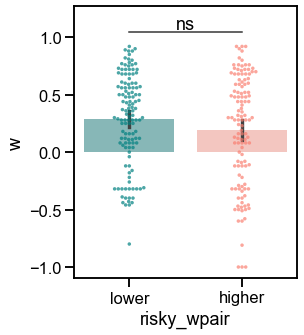

In [91]:
#compare w between risky and risk-averse
fig, ax= plt.subplots(1, 1, figsize=(4, 5))
merged['theta_wpair'] = merged.apply(lambda x: 'higher' if x['theta'] >x['mean_theta'] else 'lower', axis=1)
sns.swarmplot(data=merged, x='risky_wpair', y='w',
            alpha=0.7, s=3.5, palette=risk_colors)
sns.barplot(data=merged, x='risky_wpair', y='w', 
            alpha=0.5, palette=risk_colors)
pairs = [("higher", "lower")]
annotator = Annotator(ax, pairs, data=merged,  x='risky_wpair', y='w')
#set configurations and apply
annotator.configure(test='t-test_ind', hide_non_significant=False,
                    # comparisons_correction="bonferroni", 
                    text_format='star', loc='inside', 
                    line_height =0, text_offset=-1)#for style
annotator.apply_and_annotate()


#risky people lose money from compromising?
#people who compromised improve performance?
#y_axis: improve, x: cluster, hue='risky
# sns.catplot(data = df, y='grp_idv_step_diff', x='cluster_category', hue='risky_wpair', kind='bar')
# plt.xticks(rotation=45)
# ss.pearsonr(df.query('risky_wpair=="higher"')['grp_idv_step_diff'], df.query('risky_wpair=="higher"')['grp_idv_reward_diff'])
# on average, people performed better in groups
# d = pd.merge(merged[['subID', 'compromise', 'w', 'theta_wpair', 'theta']], 
#              pd.merge(df_group[['subID', 'room']].drop_duplicates(), group_stat))
# d = d.groupby(['subID', 'risky_wpair', 'compromise'], as_index=False)['grp_idv_reward_diff'].mean()
# sns.swarmplot(data = d, y='grp_idv_reward_diff', hue='risky_wpair', x='compromise', palette=['salmon', 'teal'],
#             dodge=True)


# fig, ax = plt.subplots(1,1,figsize=(4, 5))
# # sns.lmplot(data = d, y='reward_inc', x='w', hue='risky_wpair',
# #             scatter_kws={'s':10, 'alpha':0.5}, )
# # plt.xlabel('w')
# # plt.ylabel('$\Delta$ reward')
# # print(ss.pearsonr(d['reward_inc'], d['w']))
# d = pd.merge(params_df, group_stat.groupby(['subID'], as_index=False)[['reward_inc']].mean())
# d['compromise'] = d['w'].apply(lambda x: 'high' if x>=np.median(d['w']) else 'low')
# d['reward_inc']= d['reward_inc'] * 60
# d = pd.merge(d, merged[['subID', 'theta_wpair']])
# sns.swarmplot(data = d, y='reward_inc', x='compromise', alpha=0.4, s=4, palette=compromise_colors)
# sns.barplot(data = d, y='reward_inc', x='compromise', alpha=0.6, palette=compromise_colors)
# plt.ylabel(r'$reward_{dyad}$ - $reward_{idv}$')
# r, p = ss.ttest_ind(d.query('compromise=="high"')['reward_inc'], d.query('compromise=="low"')['reward_inc'])
# print(r, p)
# sig = get_sig(p)
# plt.text(0.5, 250, sig, ha='center', va='bottom', fontsize=24)
# plt.plot([0, 0, 1, 1], [250, 250, 250, 250], lw=1.5, color='black')
# if save:
#     plt.savefig(f'../paper_figs/{folder}/reward_by_compromise{folder}.png', 
#             bbox_inches='tight', dpi=200)

# print(ss.pearsonr(d.query('risky_wpair=="risk-prone"')['reward'], 
#                   d.query('risky_wpair=="risk-prone"')['w']))
# print(ss.pearsonr(d.query('risky_wpair=="risk-averse"')['reward'], 
#                   d.query('risky_wpair=="risk-averse"')['w']))`
# reward ~ w * risky_wpair


# plt.legend(fontsize=13, title='within dyad', title_fontsize=14)
# plt.xticks([0, 1], ['no-compromise', 'compromise'])


# plt.axhline(0, color='black', lw=0.75, ls='--')


# **One-sample t-tests against 0**
# p_values = {}
# for (comp, risky), group in d.groupby(['compromise', 'risky_wpair']):
#     if len(group) > 1:  # Ensure at least two samples for the test
#         stat, p_val = ss.ttest_1samp(group['reward_inc'], 0)
#         p_values[(comp, risky)] = p_val
#     else:
#         p_values[(comp, risky)] = np.nan  # Avoid errors with single observations

# # **Manual annotation of p-values**
# for (comp, risky), p_val in p_values.items():
#     if not np.isnan(p_val):
#         x_pos = 0 if comp=="higher" else 1  # Convert boolean to integer (0 or 1 for x-axis placement)
#         y_pos = d[(d['compromise'] == comp) & (d['risky_wpair'] == risky)]['reward_inc'].max() + 1  # Position above max value
#         plt.text(x_pos, y_pos, f"p={p_val:.3f}", ha='center', fontsize=12, color='black')

# plt.show()

#barplot for simplicity
# sns.catplot(data=df_perf, x='compromise', y='grp_idv_reward_diff', kind='bar')
# df.groupby(['compromise', 'risky_wpair'])['sub'].count()


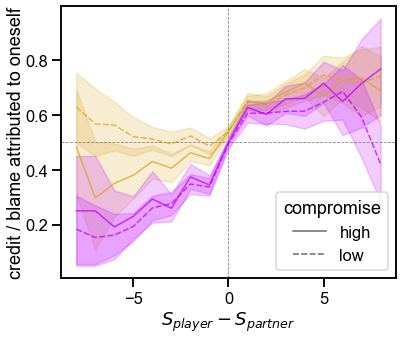

In [92]:
# separate by compromise
median_w = np.median(params_df['w'])
high_w = params_df.query('w>@median_w')['subID'].unique()
d = df_group.query('selfBlame>-1').groupby(['subID', 'attack', 'player_partner_diff'], 
                                            as_index=False)['selfBlame'].mean()
d['compromise'] = d['subID'].apply(lambda x: "high" if x in high_w else "low")
d['outcome'] = d['attack'].apply(lambda x: 'harvest' if x==False else 'captured').astype('category')
d['outcome'] = d['outcome'].cat.reorder_categories(['harvest', 'captured'], ordered=True)

#plot
plt.figure(figsize=(6, 5))
plt.axhline(0.5, ls='--', color='gray', lw=0.8)
plt.axvline(0, ls='--', color='gray', lw=0.8)
ax = sns.lineplot(
    data=d.query('player_partner_diff >= -8 and player_partner_diff<=8'), 
    x='player_partner_diff', y='selfBlame', 
    hue='outcome', 
    style='compromise', 
    palette=outcome_colors,
    alpha=0.75,
    lw = 1.5,
    style_order=['high', 'low'],
    legend='brief'  # include just one legend entry per style/hue combo
)

# Remove hue entries manually
handles, labels = ax.get_legend_handles_labels()

# Keep only unique 'style' labels (assuming 'compromise' has unique line styles)
# This assumes style names (like 'compromise' values) are in `labels`
style_labels = d['compromise'].unique().tolist()
style_handles = [h for h, l in zip(handles, labels) if l in style_labels]

#set x/y label and legend
ax.legend(style_handles, style_labels, title='compromise')
ax.set_xlabel('$S_{player} - S_{partner}$')
ax.set_ylabel('credit / blame attributed to oneself', labelpad=0.5)

if save:
    plt.savefig(f'../paper_figs/{folder}/bias_by_compromise_{folder}.png', 
            bbox_inches='tight', dpi=200)

In [93]:
# d['outcome'] = d['attack'].apply(lambda x: 'lose' if x ==True else 'win')
if np.min(d['selfBlame']) ==0:
    d['selfBlame'] = d['selfBlame'] - 0.5
model = smf.mixedlm(formula='selfBlame ~ outcome * compromise + player_partner_diff * compromise + player_partner_diff * outcome', 
                    data=d, groups = d['subID'],
                    re_formula="~ outcome + player_partner_diff + player_partner_diff * outcome"
                    )

result = model.fit()
print(result.summary())

                                   Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  selfBlame
No. Observations:                    3662                     Method:                              REML     
No. Groups:                          250                      Scale:                               0.0201   
Min. group size:                     6                        Log-Likelihood:                      1346.3387
Max. group size:                     24                       Converged:                           Yes      
Mean group size:                     14.6                                                                   
------------------------------------------------------------------------------------------------------------
                                                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------

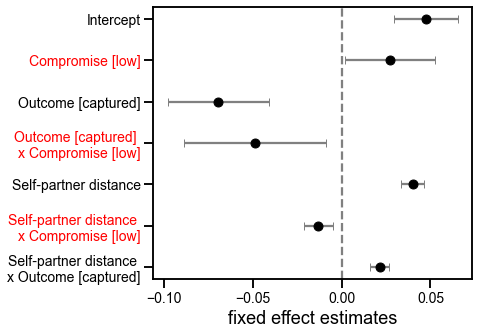

In [94]:


# Extract fixed effects and confidence intervals
fe_params = result.fe_params
ci = result.conf_int()
ci.columns = ['lower', 'upper']

# Combine into a single DataFrame
ci['estimate'] = fe_params
ci = ci.reset_index().rename(columns={'index': 'term'})

# Sort terms (optional, for cleaner plotting)
ci = ci.sort_values(by='term', ascending=False).dropna()
label_map = {
    'Intercept': 'Intercept',
    'outcome[T.captured]': 'Outcome [captured]',
    'compromise[T.low]': 'Compromise [low]',
    'player_partner_diff': 'Self-partner distance',
    'outcome[T.captured]:compromise[T.low]': 'Outcome [captured] \nx Compromise [low]',
    'player_partner_diff:compromise[T.low]': 'Self-partner distance \nx Compromise [low]',
    'player_partner_diff:outcome[T.captured]': 'Self-partner distance \nx Outcome [captured]',
}
ci['term_pretty'] = ci['term'].map(label_map)
# Plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plt.errorbar(
    x=ci['estimate'],
    y=ci['term_pretty'],
    xerr=[ci['estimate'] - ci['lower'], ci['upper'] - ci['estimate']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xlabel('fixed effect estimates')
# plt.ylabel('Term')
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() in ['Outcome [captured] \nx Compromise [low]','Compromise [low]', 'Self-partner distance \nx Compromise [low]']:
        tick_label.set_color('red')

plt.tick_params(labelsize=14) #axis='y', 
# plt.title('Fixed Effects with 95% Confidence Intervals')
plt.tight_layout()
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_betas_compromise_{folder}.png', 
            bbox_inches='tight', dpi=200)
plt.show()


In [95]:
# Convert random effects to DataFrame
random_effects = result.random_effects
betas_df = pd.DataFrame.from_dict(random_effects, orient='index')
betas_df.reset_index(inplace=True)
betas_df.rename(columns={'index': 'subID'}, inplace=True)

# Add fixed effects to get subject-level total effects
for col in result.fe_params.index:
    if col in betas_df.columns:
        betas_df[col] = betas_df[col] + result.fe_params[col]

betas_df['intercept'] = betas_df['Group'] + result.fe_params['Intercept']

betas_df['group'] = betas_df['subID'].apply(lambda x: "high" if x in high_w else "low")

In [96]:

# #ifcontinuous
# plt.figure(figsize=(6, 4.5))
# d = group_stat.copy()
# d['step_inc_directed'] = np.round(d['step_inc_directed']*2 )//2
# sns.lineplot(data = d, x='step_inc_directed', y='reward_inc', hue='risky_wpair', palette=risk_palette)
# plt.axhline(0, ls='--', color='black', lw=1)
# plt.axvline(0, ls='--', color='black', lw=1)
# plt.xlabel('compromise')
# plt.legend(loc='lower center', fontsize=14, title_fontsize=15, title='riskiness within dyad')
# plt.ylabel(r'$reward_{dyad}$ - $reward_{idv}$')
# # plt.xlim([-7, 7])

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 reward   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     427.5
Date:                Thu, 18 Dec 2025   Prob (F-statistic):          3.83e-266
Time:                        16:13:35   Log-Likelihood:                -64692.
No. Observations:               14478   AIC:                         1.294e+05
Df Residuals:                   14474   BIC:                         1.294e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             19.1366      1.357     14.102      0.000      16.477      21.796
C(predatorType)[T.1]                 -14.0697      1.920     -7.330      0.000     -17.832     -10.307
num_encounter                         -0.0278      0.030     -0.939      0.348      -0.086       0.030
num_encounter:C(predatorType)[T.1]     0.0336      0.042      0.801      0.423      -0.049       0.116
==============================================================================
Omnibus:                     1274.401   Durbin-Watson:                   1.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1642.586
Skew:                           0.782   Prob(JB):                         0.00
Kurtosis:                       3.523   Cond. No.                         656.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

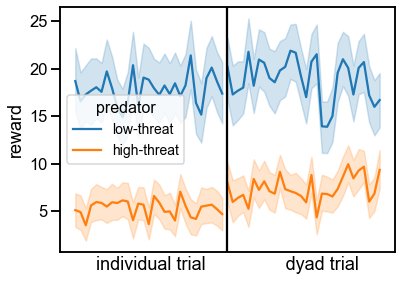

In [97]:
# control for reward by time
# no increase in reward in the later idv trials
# d = df_idv.query('trial>60').copy()

# d['cum_avg_reward'] = d.groupby(['subID', 'predatorType'])['reward'].cumsum()
# d['cum_avg_reward'] = d['cum_avg_reward'] / d['num_encounter']
# d['trial'] = d['num_encounter'] - 30
# df_group['cum_avg_reward'] = df_group.groupby(['subID', 'predatorType'])['jointMoney'].cumsum()
# df_group['cum_avg_reward'] = df_group['cum_avg_reward'] / 2/  df_group['trial']



plt.figure(figsize=(6, 4.5))
df_group['avgMoney'] = df_group['jointMoney'] / 2
sns.lineplot(data = df_idv.query('num_encounter<60 and num_encounter>30'), x='num_encounter', y='reward', 
             hue='predator', hue_order=['low-threat', 'high-threat'], legend=False)
sns.lineplot(data = df_group, x='trial', y='avgMoney', hue='predator', hue_order=['low-threat', 'high-threat'])
plt.axvline(x=30, color='black', ls='-')
plt.gca().invert_xaxis()
plt.xticks([])
plt.legend(fontsize=14, loc='center left', title='predator', title_fontsize=16)
plt.xlabel('individual trial                dyad trial')
# plt.ylim([0, 26])
if save:
    plt.savefig(f'../paper_figs/{folder}/reward_by_trial_{folder}.png', 
            bbox_inches='tight', dpi=200)

#no obv increase in individual
smf.ols("reward ~ num_encounter * C(predatorType)",
                    data=df_idv.query('num_encounter<60 and num_encounter>30'),
                    ).fit().summary()
# smf.ols("avgMoney ~ trial * C(predatorType)",
#                     data=df_group,
#                     ).fit().summary()

In [98]:
ss.ttest_1samp(group_stat.groupby('subID')['reward_inc'].mean(), 0)

TtestResult(statistic=5.0952751769261075, pvalue=6.886837008960533e-07, df=249)

# Optimality

predator 0 : 8, predator 1 : 5


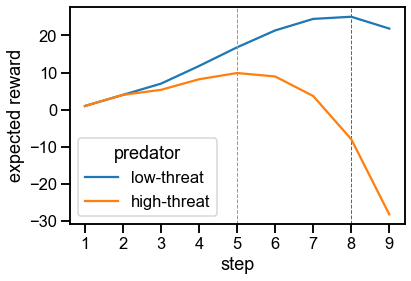

In [99]:
#plot optimal
optimal = []
predators=['low-threat', 'high-threat']
for pt in [0, 1]:
    attack_prob = df_idv.query('predatorType==@pt and choice>0').groupby(['choice'], as_index=False)['currProb'].mean()
    values = (1 - attack_prob['currProb'].values) * (attack_prob['choice'] ** 2) - attack_prob['currProb'].values * 10
    plt.plot(values, c=sns.color_palette()[pt], label=predators[pt])
    opt_step = np.argmax(values)
    plt.axvline(opt_step, ls='--', color=sns.color_palette()[pt], lw=1)
    optimal.append(opt_step + 1) #turn to 1-indexed

plt.xticks(np.arange(9), np.arange(9)+1)
plt.xlabel('step')
plt.ylabel('expected reward')
plt.legend(title='predator')


# compromise by optimality
print(f"predator 0 : {optimal[0]}, predator 1 : {optimal[1]}")
group_stat['deviation_from_optimal'] = group_stat.apply(lambda row: row['individual'] - optimal[0] if row['predator']==0 else row['individual'] - optimal[1], axis=1)

[0.5264999270439148, 0.4320000410079956]


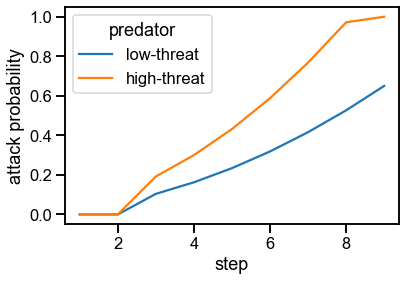

In [100]:
#plot attack rate
optimal_att = []
predators=['low-threat', 'high-threat']
for pt in [0, 1]:
    attack_prob = df_idv.query('predatorType==@pt and choice>0').groupby(['choice'])['currProb'].mean()
    attack_prob[attack_prob>1] = 1
    
    optimal_att.append(attack_prob[optimal[pt]])
    plt.plot(attack_prob, c=sns.color_palette()[pt], label=predators[pt])
    
# plt.xticks(np.arange(9), np.arange(9)+1)
plt.xlabel('step')
plt.ylabel('attack probability')
plt.legend(title='predator')
print(optimal_att)


Text(66.28319440104168, 0.5, 'compromise')

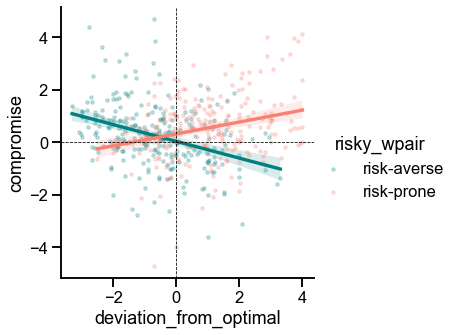

In [101]:
sns.lmplot(data = group_stat, x='deviation_from_optimal', y='step_inc_towards_partner', hue='risky_wpair',
           scatter_kws={'s':12, 'alpha':0.25}, palette=risk_palette)
plt.axhline(0, ls='--', lw=0.8, color='black')
plt.axvline(0, ls='--', lw=0.8, color='black')
plt.ylabel('compromise')

high-threat: 
PearsonRResult(statistic=0.1785688727471616, pvalue=0.004305535953503654)
low-threat: 
PearsonRResult(statistic=0.2400701515780936, pvalue=0.00010479787832909977)


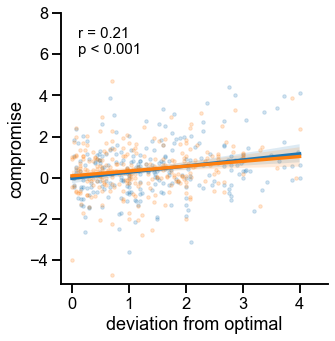

In [102]:
# sns.lmplot(data = group_stat, x='deviation_from_optimal', y='step_inc_directed', hue='risky_wpair',
#            scatter_kws={'s':15, 'alpha':0.2}, palette=risk_palette)

d = group_stat.copy()
d['deviation_from_optimal'] = np.abs(d['deviation_from_optimal'])
sns.lmplot(data = d, x='deviation_from_optimal', y='step_inc_towards_partner', hue='predator',
           scatter_kws={'s':12, 'alpha':0.2}, legend=False)
plt.ylabel('compromise')
plt.xlabel('deviation from optimal')
print("high-threat: ")
print(ss.pearsonr(d.query('predatorType==1')['deviation_from_optimal'], 
                  d.query('predatorType==1')['step_inc_towards_partner']))
print("low-threat: ")
print(ss.pearsonr(d.query('predatorType==0')['deviation_from_optimal'], 
                  d.query('predatorType==0')['step_inc_towards_partner']))

r, p= ss.pearsonr(d['deviation_from_optimal'], d['step_inc_towards_partner'])
p = f"p = {round(p, 3)}" if p>0.001 else "p < 0.001"
plt.xlim(right=4.5)
plt.ylim(top = 8)
plt.annotate(f"r = {round(r, 2)}\n{p}", xy=(0.1, 6), fontsize=15)


if save:
    plt.savefig(f'../paper_figs/{folder}/compromise_optimal_{folder}.png', 
                bbox_inches='tight', dpi=200)

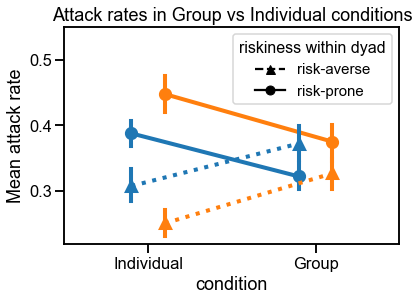

In [103]:


# Compute means
df_grp_mean = (
    df_group.groupby(['subID', 'predator'], as_index=False)['attack']
    .mean()
    .assign(condition='Group')
)

df_idv_mean = (
    df_idv.groupby(['subID', 'predator'], as_index=False)['attack']
    .mean()
    .assign(condition='Individual')
)

# Combine
df_all = pd.concat([df_idv_mean, df_grp_mean], ignore_index=True)
df_all = pd.merge(df_all, group_stat[['subID', 'predator', 'risky_wpair']], how='left')
# Plot
plt.figure(figsize=(6,4))
sns.pointplot(
    data=df_all.query('risky_wpair=="risk-prone"'),
    hue='predator',
    y='attack',
    x='condition',
    legend=False,
    dodge=0.2
    # ci='ci'   # or "se" / None, depending on what you want
)

sns.pointplot(
    data=df_all.query('risky_wpair=="risk-averse"'),
    hue='predator',
    y='attack',
    x='condition',
    marker = '^',
    ls=':',
    legend=False,
    dodge=0.2
    # ci='ci'   # or "se" / None, depending on what you want
)
plt.ylabel("Mean attack rate")
plt.ylim(top=0.55)
# plt.xlabel("Predator type")
plt.title("Attack rates in Group vs Individual conditions")
legend_handles = [
    Line2D([0], [0], color='black', ls='--', marker='^', label='risk-averse'),
    Line2D([0], [0], color='black', ls='-', marker='o', label='risk-prone')
]
plt.legend(handles = legend_handles, title='riskiness within dyad', title_fontsize=16, fontsize=15)



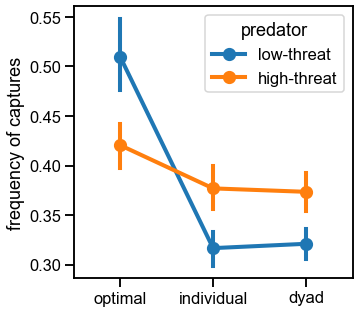

In [104]:
# sns.barplot(data = df_group.query('(predatorType==0 and finalStep==8) or (predatorType==1 and finalStep==5)'), x='predatorType', y='attack')
# sns.barplot(data = df_group.groupby(['subID', 'predatorType'], as_index=False)['attack'].mean(), x='predatorType', y='attack')
# sns.barplot(data = df_idv.groupby(['subID', 'predatorType'], as_index=False)['attack'].mean(), x='predatorType', y='attack')

# 1. Prepare your three datasets with a new column "source"
d1 = df_group.query('(predatorType==0 and finalStep==8) or (predatorType==1 and finalStep==5)').copy()
d1['source'] = "optimal"

d2 = df_group.groupby(['subID', 'predator'], as_index=False)['attack'].mean()
d2['source'] = "dyad"

d3 = df_idv.groupby(['subID', 'predator'], as_index=False)['attack'].mean()
d3['source'] = "individual"

# 2. Combine
df_all = pd.concat([d1[['predator','attack','source']],
                    d3[['predator','attack','source']],
                    d2[['predator','attack','source']]])

# 3. Plot
plt.figure(figsize=(5,5))
sns.pointplot(data=df_all, hue='predator', y='attack', x='source', hue_order=['low-threat', 'high-threat'])
plt.ylabel("frequency of captures")
plt.xlabel("")
# plt.title("Attack by predator type across datasets")
plt.legend(title="predator")
# plt.axhline(optimal_att[0], ls='--')
# plt.axhline(optimal_att[1], ls='--')
if save:
    plt.savefig(f'../paper_figs/{folder}/attack_prob_{folder}.png', 
                bbox_inches='tight', dpi=200)

In [105]:
# #step inc is group - individual
# # compromise ~ optimality
# d = group_stat.copy()
# d['deviation_from_optimal'] = round(d['deviation_from_optimal'])
# # sns.lmplot(data = group_stat, x='deviation_from_optimal', y='step_inc', hue='risky_wpair')
# sns.lineplot(data = d, x='deviation_from_optimal', y='step_inc', style='risky_wpair', hue='predatorType')
# plt.legend().remove()

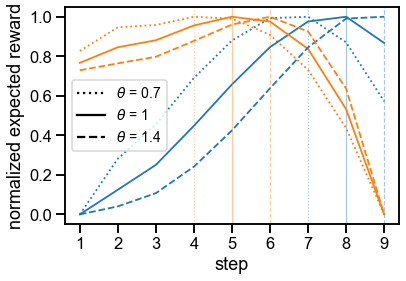

In [106]:
# plot EV: show effet of Theta
optimal = []
lss = [':', '-', '--']
thetas = [0.7, 1, 1.4]

for t, theta in enumerate(thetas):
    for pt in [0, 1]:
        attack_prob = df_idv.query('predatorType==@pt and choice>0').groupby(['choice'], as_index=False)['currProb'].mean()
        values = (1 - attack_prob['currProb'].values) * (attack_prob['choice'] ** 2) ** theta - attack_prob['currProb'].values * (10 ** theta)
        plt.plot((values - np.min(values)) / (np.max(values) - np.min(values)), ls=lss[t], c=sns.color_palette()[pt], lw=1.8)
        plt.axvline(x=np.argmax(values),ls=lss[t], c=sns.color_palette()[pt], alpha=0.4, lw=1.2)

plt.xticks(np.arange(9), np.arange(9)+1)
plt.xlabel('step')
plt.ylabel('normalized expected reward')


legend_handles = [
    Line2D([0], [0], color='black', ls=lss[i], label=rf"$\theta$ = {thetas[i]}")
    for i in range(len(lss))
]

plt.legend(handles=legend_handles, loc='center left', fontsize=14)


In [120]:
#blame ~ player_partner_diff + attack + player_partner_diff * if_attack + player_parnter_diff * if_w_high + attack * if_w_high + player_partner_diff * if_attack * if_whigh
# d2 = df_group.copy()
# high_w_subs = params_df.query('w>@median_w')['subID'].unique()
# d2['w_high'] = d2['subID'].apply(lambda x: True if x in high_w_subs else False)
# d2['win'] = d2['attack'].apply(lambda x: True if not x else False)
# d2['win_highC'] = d2.apply(lambda x: x['win'] if x['w_high'] else 0, axis=1)
# d2['player_partner_diff_highC'] = d2.apply(lambda x: x['player_partner_diff'] if x['w_high'] else 0, axis=1)
# d2['int_highC'] = d2.apply(lambda x: x['player_partner_diff'] if (x['w_high'] and x['win']) else 0, axis=1)
# # Run the regression using the formula
# model = smf.mixedlm(formula='selfBlame ~ player_partner_diff + win + player_partner_diff * win + win_highC + player_partner_diff_highC', 
#                     data=d2, groups = d2['subID'])

# result = model.fit(method="lbfgs", maxiter=1000)

# # Print the summary of the model

# print(result.summary())

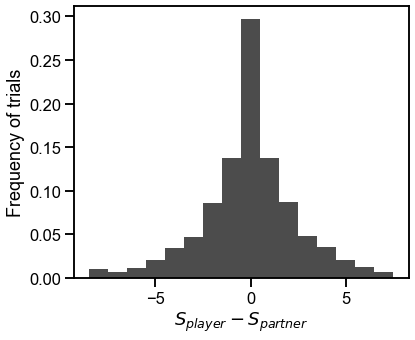

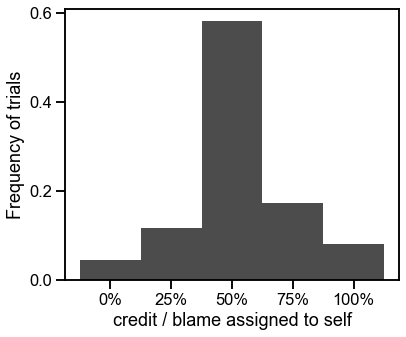

In [114]:
#distribution of player partner difference
# x = df_group.groupby(['player_partner_diff', 'subID', 'predatorType'], as_index=False)['trial'].count()
# x['player_partner_diff']= x['player_partner_diff'].astype(int)
# sns.barplot(data = x, x='player_partner_diff', y='trial', hue='predatorType')
plt.figure(figsize=(6, 5))
plt.hist(df_group['player_partner_diff'], bins=np.arange(-8, 9)-0.5, density=True, 
         color='black', alpha=0.7)
plt.ylabel('Frequency of trials')
plt.xlabel('$S_{player} - S_{partner}$')
if save: 
    plt.savefig(f'../paper_figs/{folder}/ppd_dist_{folder}.png', bbox_inches='tight', dpi=200)

plt.figure(figsize=(6, 5))
plt.hist(df_group.query('selfBlame!=-1')['selfBlame'], bins=np.arange(0, 1.2, 0.2), density=True, 
         color='black', alpha=0.7)
plt.ylabel('Frequency of trials')
plt.xticks(np.arange(0.1, 1.1, 0.2), ['0%', '25%', '50%', '75%', '100%'])
plt.yticks(np.arange(0, 3.5), np.arange(0, 3.5)/5)
plt.xlabel('credit / blame assigned to self')
if save:
    plt.savefig(f'../paper_figs/{folder}/blame_dist_{folder}.png', bbox_inches='tight', dpi=200)
# d= df_group.query('selfBlame!=-1').groupby(['subID', 'selfBlame'], as_index=False)['trial'].count()
# sns.boxplot(data=d, x='selfBlame', y='trial')

# calculate social reward

In [115]:
social_reward = df_group.copy()
social_reward['partner_assigned_reward'] = (1 - social_reward['partnerBlame']) * social_reward['jointMoney']
social_reward['self_assigned_reward'] = social_reward['selfBlame'] * social_reward['jointMoney']
## swap blame for attack
social_reward['partnerBlame'] = social_reward.apply(lambda row: row['partnerBlame'] if row['attack']==0 else 1-row['partnerBlame'], axis=1)
social_reward['selfBlame'] = social_reward.apply(lambda row: row['selfBlame'] if row['attack']==0 else 1-row['selfBlame'], axis=1)

social_reward_g = pd.merge(social_reward.query('selfBlame>-1 and selfBlame<2').groupby(['subID', 'room'], as_index=False)[['self_assigned_reward', 'selfBlame']].mean(),
                         social_reward.query('partnerBlame>-1 and partnerBlame<2').groupby(['subID', 'room'], as_index=False)[['partner_assigned_reward', 'partnerBlame']].mean())
social_reward_g = pd.merge(social_reward_g, params_df)
social_reward_g['partnerBlame'] = 1 - social_reward_g['partnerBlame']
social_reward_g = pd.merge(social_reward_g, social_reward_g.groupby(['room'], as_index=False)['theta'].mean().rename({'theta':'theta_wpair'}, axis=1),
                         how='left')
social_reward_g['theta_wpair'] = social_reward_g.apply(lambda row: 'higher' if row['theta'] >row['theta_wpair'] else 'lower', axis=1)
social_reward_g['compromise'] = social_reward_g.apply(lambda row: 'high' if row['w']>np.median(social_reward_g['w']) else 'low', axis=1)
print(len(social_reward_g))

250


0.18821131818321157 0.002810715608420639
-0.18423415379445712 0.0034615922747815026


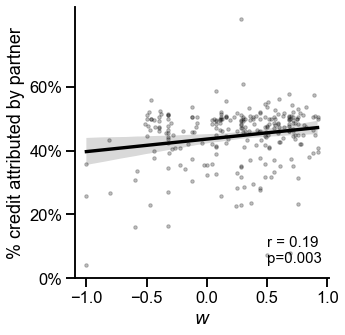

<Figure size 432x288 with 0 Axes>

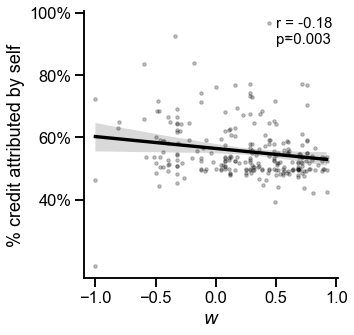

In [119]:
sns.lmplot(data = social_reward_g, x='w', y='partnerBlame', 
           scatter_kws={'s':12, 'alpha':0.25, 'color':'black'}, line_kws={'color':'black'})
r,p = ss.pearsonr(social_reward_g['partnerBlame'], social_reward_g['w'])
print(r, p)

p = f"p={round(p, 3)}" if p>=0.001 else "p < 0.001"
plt.annotate(f"r = {round(r, 2)}\n{p}", xy=(0.5, 0.05), fontsize=15)
plt.ylabel('% credit attributed by partner')
plt.yticks([0, 0.2, 0.4, 0.6], ['0%', '20%', '40%', '60%'])
plt.xlabel('$w$')
# sns.swarmplot(data = social_reward_g, x='compromise', y='partner_assigned_reward')
# sns.barplot(data = social_reward_g, x='compromise', y='partner_assigned_reward')
# print(ss.ttest_ind(social_reward_g.query('compromise =="high"')['partner_assigned_reward'], 
#                    social_reward_g.query('compromise =="low"')['partner_assigned_reward']))
if save:
    plt.savefig(f'../paper_figs/{folder}/partnerBlame_w_{folder}.png', 
                bbox_inches='tight', dpi=200)

plt.figure()
sns.lmplot(data = social_reward_g, x='w', y='selfBlame',
           scatter_kws={'s':12, 'alpha':0.25, 'color':'black'}, line_kws={'color':'black'})
r, p = ss.pearsonr(social_reward_g['selfBlame'], social_reward_g['w'])
print(r, p)

p = f"p={round(p, 3)}" if p>=0.001 else "p < 0.001"
plt.annotate(f"r = {round(r, 2)}\n{p}", xy=(0.5, 0.9), fontsize=15)
plt.ylabel('% credit attributed by self')
plt.yticks([0.4, 0.6, 0.8, 1], ['40%', '60%', '80%', '100%'])
plt.xlabel('$w$')
if save:
    plt.savefig(f'../paper_figs/{folder}/selfBlame_w_{folder}.png', 
                bbox_inches='tight', dpi=200)
# sns.swarmplot(data = social_reward, x='compromise', y='self_assigned_reward')
# sns.barplot(data = social_reward, x='compromise', y='self_assigned_reward')
# print(ss.ttest_ind(social_reward.query('compromise =="high"')['self_assigned_reward'], 
#                    social_reward.query('compromise =="low"')['self_assigned_reward']))

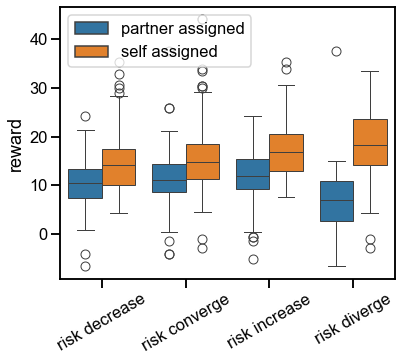

In [117]:

# social_reward_g2 = pd.merge(social_reward.query('selfBlame>-1').groupby(['subID', 'room', 'predatorType'], as_index=False)['self_assigned_reward'].mean(),
#                          social_reward.query('partnerBlame>-1').groupby(['subID', 'room', 'predatorType'], as_index=False)['partner_assigned_reward'].mean())
social_reward_g2= pd.merge(social_reward_g, collapsed_g[['room', 'predatorType', 'cluster']])

# sns.barplot(data=social_reward_g, x='cluster', y='partner_assigned_reward')
# plt.figure()
# sns.barplot(data=social_reward_g, x='cluster', y='self_assigned_reward')

# Reshape to long format
df_long = social_reward_g2.melt(
    id_vars=['cluster'],
    value_vars=['partner_assigned_reward', 'self_assigned_reward'],
    var_name='reward_type',
    value_name='reward'
)
df_long= df_long.replace({'partner_assigned_reward':'partner assigned', 'self_assigned_reward':'self assigned'})
# Plot with hue
plt.figure(figsize=(6,5))
# myswarm(data=df_long, x='cluster', y='reward', hue='reward_type', dodge=True, legend=False)
# mybar(data=df_long, x='cluster', y='reward', hue='reward_type')
sns.boxplot(data=df_long, x='cluster', y='reward', hue='reward_type')

# plt.ylabel("Assigned reward")
plt.xlabel("")
plt.xticks(rotation=30)
plt.legend(loc='upper left')
plt.show()


Text(0.5, 0, '')

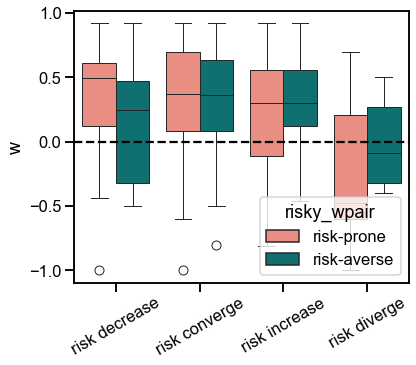

In [118]:
social_reward_g2 = pd.merge(social_reward_g2, group_stat)
social_reward_g2 = pd.merge(social_reward_g2, params_df)
plt.figure(figsize=(6,5))
# mybar(data = social_reward_g2, x='cluster', y='w', hue='risky_wpair')
# myswarm(data = social_reward_g2, x='cluster', y='w', hue='risky_wpair', dodge=True, legend=False)
sns.boxplot(data = social_reward_g2, x='cluster', y='w', hue='risky_wpair', palette=risk_palette)
plt.axhline(0, ls='--', color='black')
plt.xticks(rotation=30)
plt.xlabel("")

# For rep2 only

In [ ]:
# Data processing for individual and group foraging
#get  post individual choice
gi2 = df_idv2.groupby(['subID', 'predatorType'], as_index=False)[['choice', 'reward']].mean()
gi2 = gi2.rename({'choice':'choice_post', 'reward':'reward_post'}, axis=1)

# get group choice
g_new = pd.merge(gi2, group_stat_filtered[['room', 'risky_wpair', 'predatorType', 'subID', 'group', 'jointMoney', 'individual', 'reward']])


TtestResult(statistic=3.8210259141567344, pvalue=0.0001766367745014476, df=203)
Cohen's d for risk-prone: -0.2675253244074299
TtestResult(statistic=2.0571403994135338, pvalue=0.040938637099007164, df=205)
Cohen's d for risk-averse: 0.14332776313044537


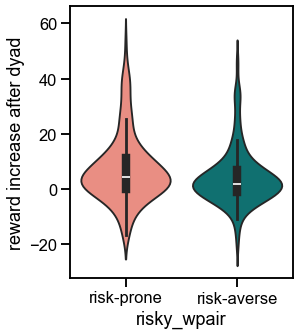

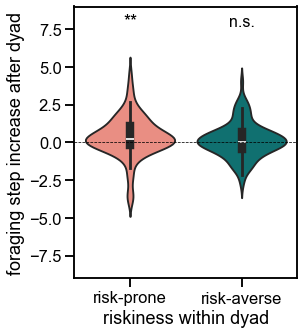

In [ ]:
# #compare money increase between risky and risk-averse individuals
g_new['reward_inc'] = g_new['reward_post'] - g_new['jointMoney'] / 2
g_new['step_inc'] = g_new['choice_post'] - g_new['group']

plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='reward_inc', x='risky_wpair', palette=risk_palette)
plt.ylabel('reward increase after dyad')

plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='step_inc', x='risky_wpair', palette=risk_palette, 
            # flierprops=dict(markersize=8, alpha=0.7)
            )
plt.xlabel('riskiness within dyad')
plt.ylabel('foraging step increase after dyad')
plt.text(1, 8, "n.s.", ha='center', va='center', fontsize=16) #this is based on regression runned later
plt.text(0, 8, "**", ha='center', va='center', fontsize=18) #this is based on regression runned later
plt.ylim([-9, 9])
plt.axhline(0, color='black', lw=0.75, ls='--')

plt.savefig(f'../paper_figs/{folder}/step_inc_{folder}.png', 
            bbox_inches='tight', dpi=200)


print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-prone"')['step_inc'], 0))
sample =g_new.query('risky_wpair=="risk-prone"')['step_inc']
mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-prone: {cohens_d}")


print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-averse"')['step_inc'], 0))
sample =g_new.query('risky_wpair=="risk-averse"')['step_inc']
mean_diff = np.mean(sample) - 0  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-averse: {cohens_d}")




TtestResult(statistic=-2.0403229771118196, pvalue=0.04261302267739551, df=203)
Cohen's d for risk-prone: 0.14285118149172085
TtestResult(statistic=6.002375106732473, pvalue=8.705333956829566e-09, df=205)
Cohen's d for risk-averse: 0.4182052901022686


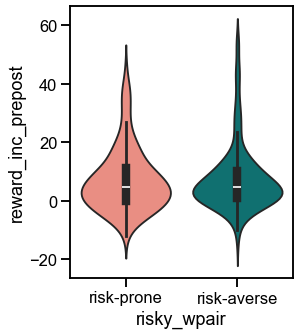

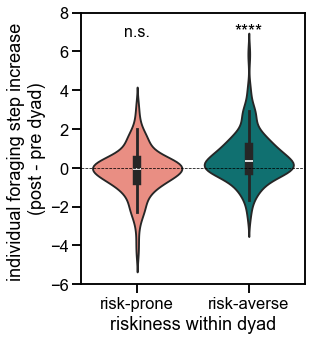

In [ ]:
# #compare money increase between risky and risk-averse individuals
g_new['step_inc_prepost'] = g_new['choice_post'] - g_new['individual']
# g_new['step_inc'] = g_new['choice_post'] - g_new['group']
g_new['reward_inc_prepost'] =g_new['reward_post'] -  g_new['reward']

plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='reward_inc_prepost', x='risky_wpair', palette=risk_palette)


plt.figure(figsize=(4, 5))
sns.violinplot(data=g_new, y='step_inc_prepost', x='risky_wpair', palette=risk_palette, 
            # flierprops=dict(markersize=8, alpha=0.7)
            )

# need to correct for multiple comparison?
plt.xlabel('riskiness within dyad')
plt.ylabel('individual foraging step increase \n(post - pre dyad)')
plt.text(0, 7, "n.s.", ha='center', va='center', fontsize=16) #this is based on regression runned later
plt.text(1, 7, "****", ha='center', va='center', fontsize=18) #this is based on regression runned later
plt.ylim([-6, 8])
plt.axhline(0, color='black', lw=0.75, ls='--')



print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-prone"')['step_inc_prepost'], 0))
sample =g_new.query('risky_wpair=="risk-prone"')['step_inc_prepost']
mean_diff = 0 - np.mean(sample)  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-prone: {cohens_d}")


print(ss.ttest_1samp(g_new.query('risky_wpair=="risk-averse"')['step_inc_prepost'], 0))
sample =g_new.query('risky_wpair=="risk-averse"')['step_inc_prepost']
mean_diff = np.mean(sample) - 0  # or just np.mean(sample)
std_dev = np.std(sample, ddof=1)  # use ddof=1 for sample std
cohens_d = mean_diff / std_dev
print(f"Cohen's d for risk-averse: {cohens_d}")


plt.savefig(f'../paper_figs/{folder}/step_inc_prepost_{folder}.png', 
            bbox_inches='tight', dpi=200)


# visualize models

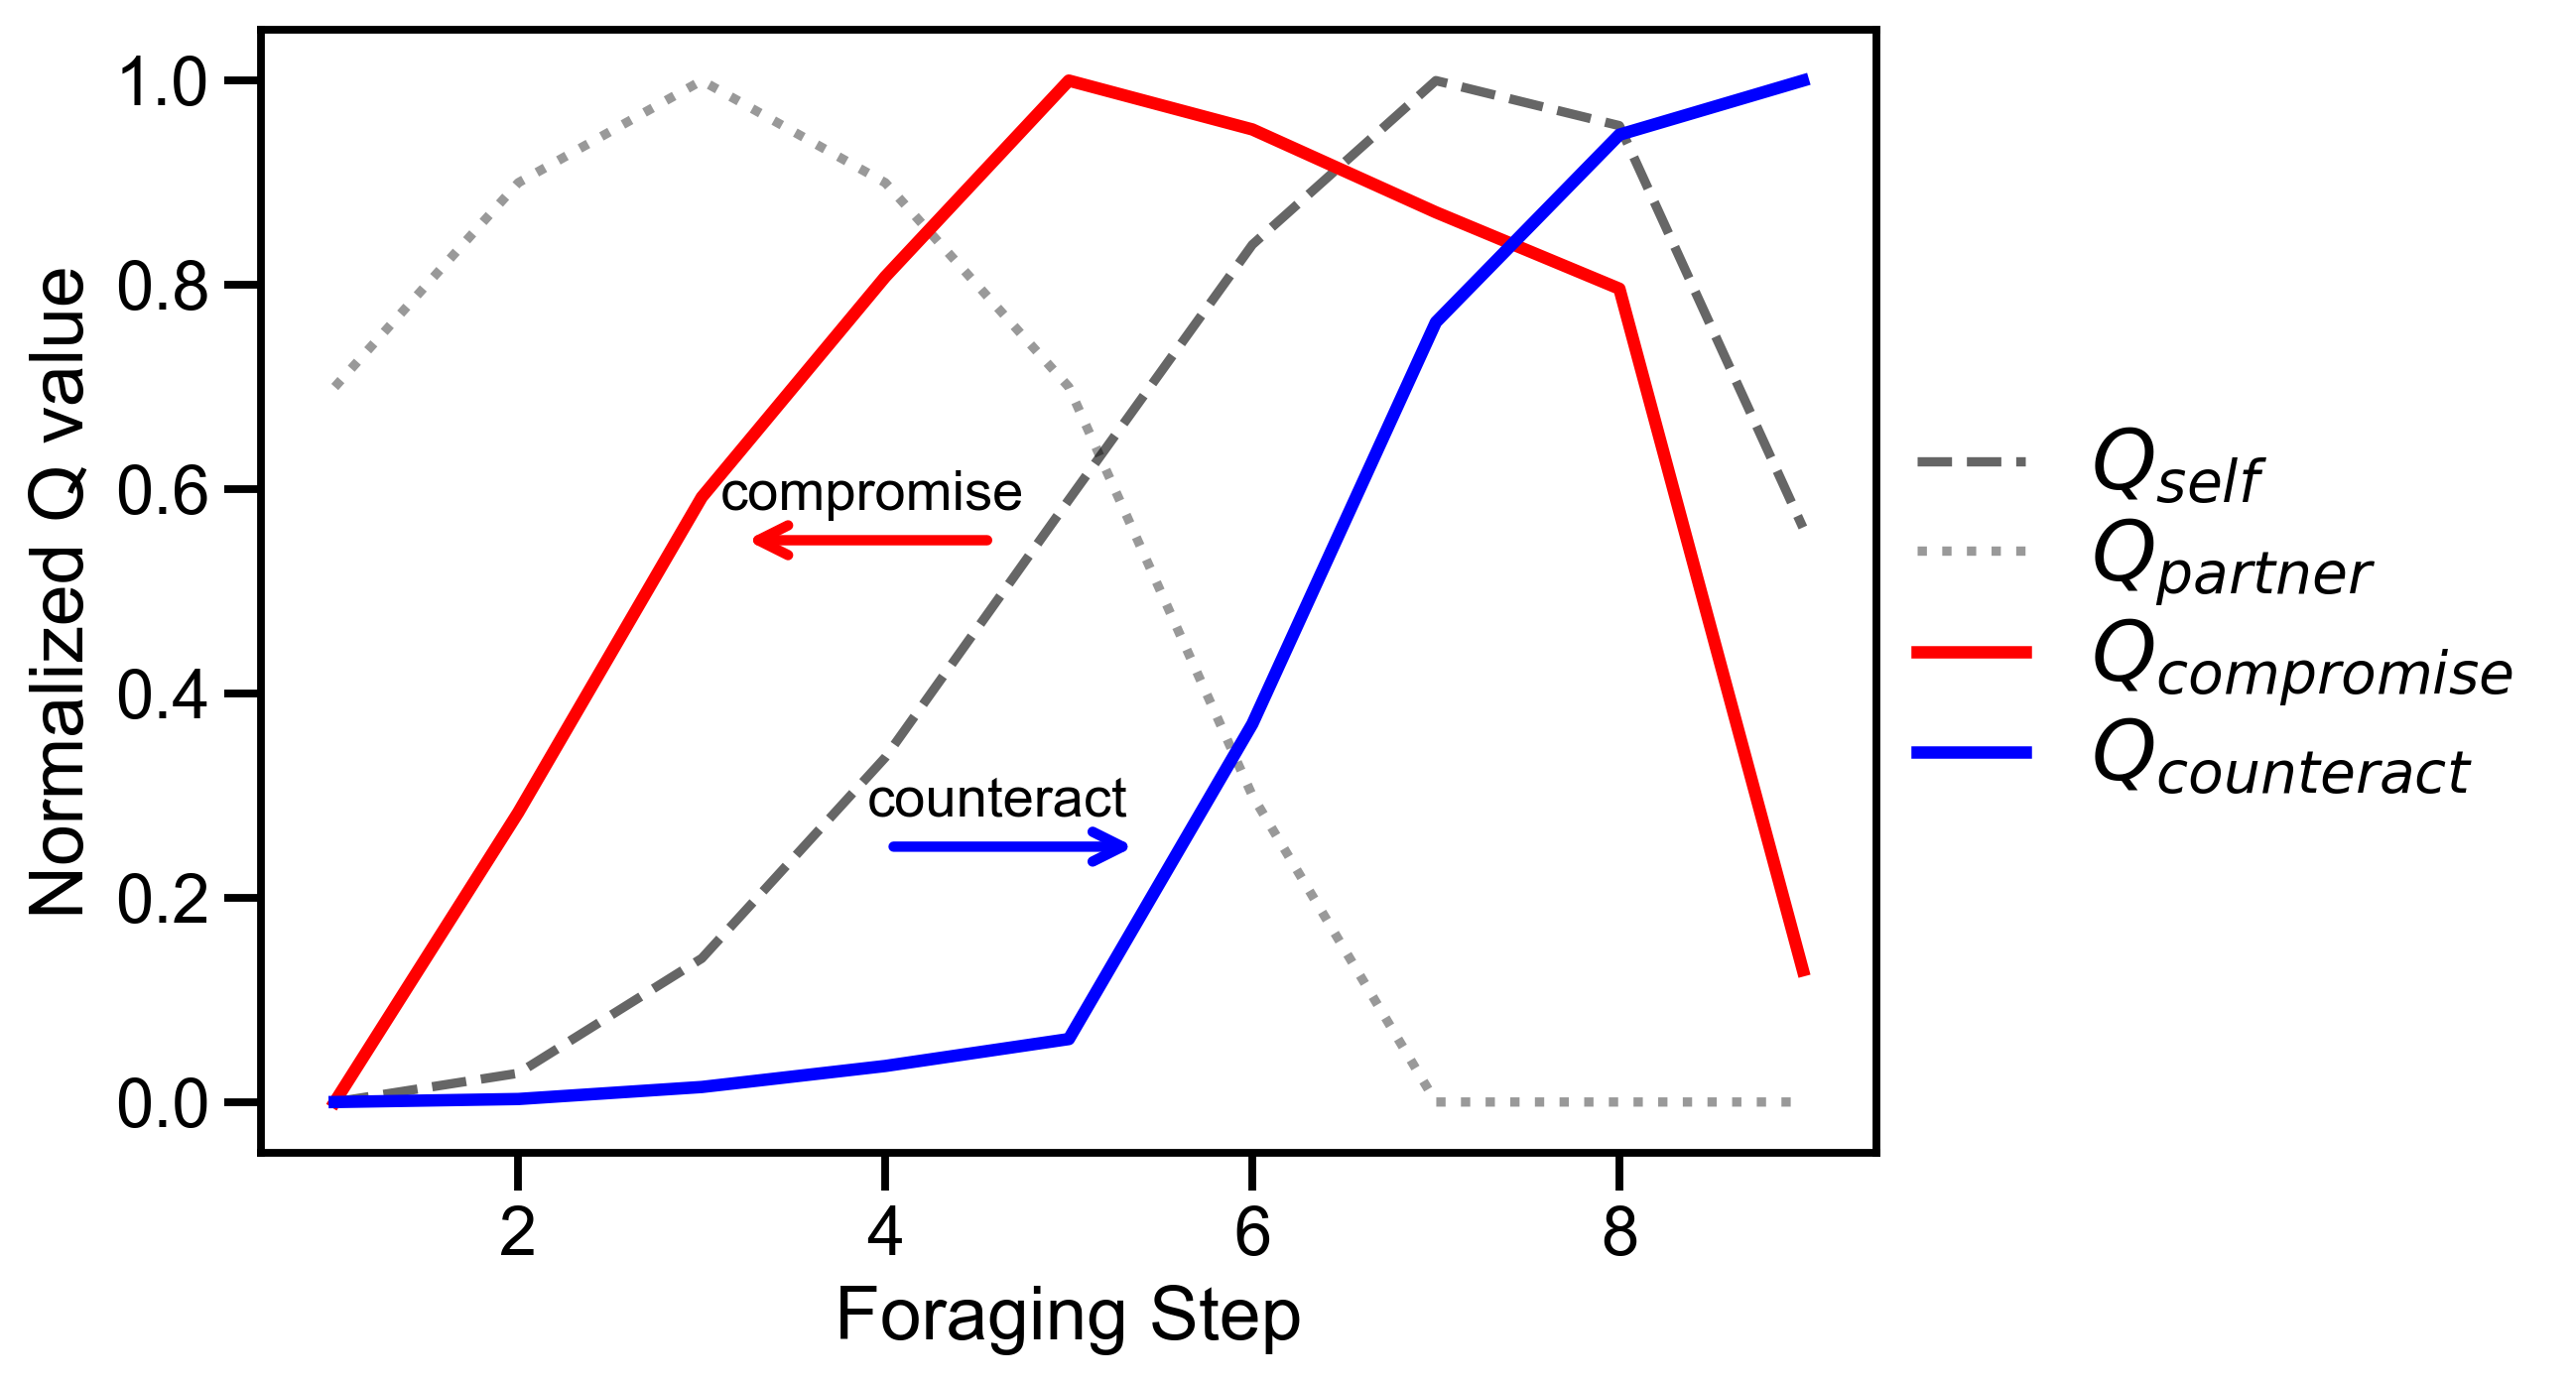

In [ ]:
#how this model work?
sns.set_context("talk")
#game setups
X = np.arange(1, 10)
rewards = X ** 2
#set params
w1 = 0.41
theta = 1.5
#set v_safety
V_safety = np.array([0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1])
#get Q_self
Q_self = V_safety * rewards ** theta - (1 - V_safety) * 10 ** theta
Q_self = (Q_self - min(Q_self)) / (max(Q_self) - min(Q_self))
#get Q_partner
pred_other_step = 3
Q_partner = np.array([max(1.1 - 0.1 * 2 ** abs(i - pred_other_step), 0) for i in X])
Q = w1 * Q_partner + (1-w1) * Q_self
Q1 = (Q - min(Q)) / (max(Q) - min(Q))
# Q = np.array([max(Q_self[i-1] - w * np.sqrt(abs(i - pred_other_step)), 0) for i in X])

w2 = -0.9
compensate = max(min(2 * np.argmax(Q_self) - pred_other_step, 0), 9)
Q_partner_c = np.array([max(1.1 - 0.1 * 2 ** abs(i - compensate), 0) for i in X])
Q = -w2 * Q_partner_c + (1+w2) * Q_self
Q2 = (Q - min(Q)) / (max(Q) - min(Q))
# w2=0.5
# Q2 = w2 * Q_partner + (1-w2) * Q_self
# Q2 = (Q2 - min(Q2)) / (max(Q2) - min(Q2))
# normalize Q?
# beta = 5
# Q_self = np.exp(Q_self * beta) / np.sum(np.exp(Q_self * beta))
# Q = np.exp(Q * beta) / np.sum(np.exp(Q * beta))
# Q_partner= Q_partner / sum(Q_partner)

# colors = ['firebrick', 'steelblue']
colors = ['red', 'blue'] 
plt.figure(figsize=(7, 5), dpi=300)
plt.plot(X, Q_self, label='$Q_{self}$', ls='--', color='black', alpha=0.6)
plt.plot(X, Q_partner, label='$Q_{partner}$', ls=':', color='black', alpha=0.4)
plt.plot(X, Q1, label = '$Q_{compromise}$', ls='-', color=colors[0], linewidth=3) #, marker='o'
plt.plot(X, Q2, label = '$Q_{counteract}$', ls='-', color=colors[1], linewidth=3)
plt.xlabel('Foraging Step')
plt.ylabel('Normalized Q value')
plt.legend(fontsize=20, labelspacing=0.1, loc='lower center', handlelength=1.3,
           bbox_to_anchor=(1.21, 0.25), frameon=False)

#annotate
plt.annotate("compromise", xy=(3.1, 0.58), fontsize=13.5)
plt.annotate("", xy=(3.2, 0.55), xytext=(4.6, 0.55), 
             arrowprops=dict(arrowstyle="->", color=colors[0], lw=2.5))
plt.annotate("counteract", xy=(3.9, 0.28), fontsize=13.5)
plt.annotate("", xy=(5.4, 0.25), xytext=(4.0, 0.25), 
             arrowprops=dict(arrowstyle="->", color=colors[1], lw=2.5))
plt.show()